# Spain vs France: xT Style and Tactical Matchup Prediction

Previous notebooks created three xT tactical clustering experiments. Experiment A clusters raw xT spatial distributions, Experiment B clusters smoothed xT spatial distributions, and Experiment C clusters multi-channel xT features. A separate tactical statistics model analyzes formations, tactical indicators, and historical matchup results.

These models remain separate analytical modules. This notebook connects their outputs only at the final interpretation and prediction stage. No new complex machine-learning model is required; the goal is to demonstrate an end-to-end football analytics workflow for **Spain vs France**, a neutral-site 2026 FIFA World Cup semifinal scheduled for **2026-07-14**.

The prediction is based on historical proxy data because current World Cup event-level data is unavailable in this project. The workflow does not fabricate current tournament events, lineups, injuries, formations, or xT values.

## xT clustering module

Used to describe where a team creates threat, where it receives threat, pass-created xT, carry-created xT, attacking spatial concentration, and similarity to historical tactical clusters.

## Tactical statistics module

Used to describe formation frequencies, formation-versus-formation historical results, tactical indicators, possible matchup advantages, sample sizes, and uncertainty.

## Final prediction layer

Used to combine a historical team strength prior, xT style matchup information, tactical or formation matchup information, and simple transparent scoring rules.

> The final probability is a demonstration of model integration. It should not be interpreted as a reliable betting probability.

## Configuration

Experiment C is the default primary xT model. Experiments A and B are loaded and displayed when available, but cluster labels from different KMeans models are not directly comparable and are not majority-voted.

In [1]:
from pathlib import Path
import json
import math
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = lambda text: text

TARGET_MATCH = {
    "team_a": "Spain",
    "team_b": "France",
    "match_name": "Spain vs France",
    "competition_name": "2026 FIFA World Cup",
    "round_name": "Semifinal",
    "match_date": "2026-07-14",
    "neutral_site": True
}

PRIMARY_XT_EXPERIMENT = "C"
AVAILABLE_XT_EXPERIMENTS = ["A", "B", "C"]
USE_ALL_EXPERIMENTS_FOR_COMPARISON = True
USE_TACTICAL_STATISTICS = True
USE_RULE_BASED_FINAL_PREDICTION = True
USE_SUPERVISED_MODEL_IF_ALREADY_AVAILABLE = True
RECENT_HISTORICAL_MATCH_COUNT = 10
MIN_CLUSTER_MATCHUP_SAMPLE = 10
MIN_FORMATION_MATCHUP_SAMPLE = 10
RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs/spain_france_prediction")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(json.dumps(TARGET_MATCH, indent=2))

c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Output directory: D:\UIUC\Projects\World Cup 2026\outputs\spain_france_prediction
{
  "team_a": "Spain",
  "team_b": "France",
  "match_name": "Spain vs France",
  "competition_name": "2026 FIFA World Cup",
  "round_name": "Semifinal",
  "match_date": "2026-07-14",
  "neutral_site": true
}


## Discover Available Project Files

The workflow inventories local CSV, PKL, JSON, notebook, text, and model-artifact files. It searches `outputs/`, `data/`, `models/`, and the project root, then saves a categorized file inventory.

In [2]:
PROJECT_ROOT = Path.cwd()
SEARCH_ROOTS = [PROJECT_ROOT / "outputs", PROJECT_ROOT / "data", PROJECT_ROOT / "models", PROJECT_ROOT]
SEARCH_EXTENSIONS = {".csv", ".pkl", ".json", ".ipynb", ".txt", ".joblib", ".pickle"}

CATEGORY_PATTERNS = {
    "xT clustering outputs": ["clustered_team_seasons", "experiment_", "cluster_metric"],
    "xT feature datasets": ["team_season_xt", "xt_distribution", "xt_clustering_features", "xt_grid", "global_xt"],
    "cluster summaries": ["cluster_summary", "cluster_channel_summary", "cluster_top_zones", "cluster_naming"],
    "cluster representatives": ["cluster_representatives"],
    "cluster centroids": ["cluster_centroid", "cluster_centroids"],
    "saved scaler, PCA, and KMeans artifacts": ["scaler", "pca", "kmeans", ".pkl", ".joblib", ".pickle"],
    "match metadata": ["match_metadata", "match_rows", "matches"],
    "match results": ["results", "score", "goals", "match_rows"],
    "formation statistics": ["formation"],
    "tactical statistics": ["tactical", "matchup", "counter", "strategy", "statistics", "favorable", "unfavorable"],
    "previously trained prediction models": ["prediction", "model", "logistic", "random_forest", "xgboost", "calibration"],
}

def rel(path):
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def categorize_file(path):
    name = path.name.lower()
    full = str(path).lower()
    hits = []
    for category, patterns in CATEGORY_PATTERNS.items():
        if any(pattern.lower() in name or pattern.lower() in full for pattern in patterns):
            hits.append(category)
    return "; ".join(hits) if hits else "other relevant local file"

def discover_project_files():
    seen = set()
    rows = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        iterator = root.rglob("*") if root != PROJECT_ROOT else root.glob("*")
        for path in iterator:
            if path.is_file() and path.suffix.lower() in SEARCH_EXTENSIONS:
                resolved = path.resolve()
                if resolved in seen:
                    continue
                seen.add(resolved)
                rows.append({
                    "category": categorize_file(path),
                    "path": rel(path),
                    "suffix": path.suffix.lower(),
                    "size_bytes": path.stat().st_size,
                })
    return pd.DataFrame(rows).sort_values(["category", "path"]).reset_index(drop=True)

project_file_inventory = discover_project_files()
project_file_inventory.to_csv(OUTPUT_DIR / "project_file_inventory.csv", index=False)
print(f"Discovered {len(project_file_inventory)} relevant local files.")
for category, group in project_file_inventory.groupby("category"):
    print(f"\n[{category}] {len(group)} file(s)")
    for path in group["path"].head(20):
        print(f"  - {path}")
    if len(group) > 20:
        print(f"  ... {len(group) - 20} more")
display(project_file_inventory.head(30))

Discovered 91 relevant local files.

[formation statistics; previously trained prediction models] 1 file(s)
  - outputs\spain_france_prediction\spain_france_formation_scenarios.csv

[formation statistics; tactical statistics] 1 file(s)
  - outputs\formation_matchup_summary.csv

[match metadata] 1 file(s)
  - outputs\match_metadata.csv

[match metadata; match results; formation statistics] 1 file(s)
  - outputs\formation_match_rows.csv

[other relevant local file] 14 file(s)
  - 05_team_xt_surface_visualization.ipynb
  - 07A_clustering_raw_xt_matrix.ipynb
  - 07B_clustering_smoothed_xt_matrix.ipynb
  - 07C_clustering_multichannel_xt_features.ipynb
  - 10_predict_spain_vs_france_world_cup_semifinal.ipynb
  - outputs\player_xt_ranking.csv
  - outputs\team_end_zone_xt_raw.csv
  - outputs\team_season_action_count_start_wide.csv
  - outputs\team_start_zone_xt_raw.csv
  - outputs\team_xt_ranking.csv
  - outputs\team_xt_spatial_summary.csv
  - outputs\xt_matrix_build_log.txt
  - requirements.t

,category,path,suffix,size_bytes
0,formation statistics; previously trained predi...,outputs\spain_france_prediction\spain_france_f...,.csv,1265
1,formation statistics; tactical statistics,outputs\formation_matchup_summary.csv,.csv,13349
2,match metadata,outputs\match_metadata.csv,.csv,353911
3,match metadata; match results; formation stati...,outputs\formation_match_rows.csv,.csv,730831
4,other relevant local file,05_team_xt_surface_visualization.ipynb,.ipynb,1065342
5,other relevant local file,07A_clustering_raw_xt_matrix.ipynb,.ipynb,549093
6,other relevant local file,07B_clustering_smoothed_xt_matrix.ipynb,.ipynb,621972
7,other relevant local file,07C_clustering_multichannel_xt_features.ipynb,.ipynb,63280
8,other relevant local file,10_predict_spain_vs_france_world_cup_semifinal...,.ipynb,86975
9,other relevant local file,outputs\player_xt_ranking.csv,.csv,34785


## Robust Schema Inspection

Every loaded CSV is inspected for path, shape, columns, first rows, and likely team, season, competition, cluster, feature, result, score, and formation columns.

In [3]:
TEAM_COL_CANDIDATES = ["team", "team_name", "team_label", "home_team", "away_team", "home_team_name", "away_team_name"]
SEASON_COL_CANDIDATES = ["season", "season_name", "season_id", "year"]
COMPETITION_COL_CANDIDATES = ["competition", "competition_name", "competition_id", "country_name"]
CLUSTER_COL_CANDIDATES = ["cluster_raw", "cluster_smoothed", "cluster_multichannel", "cluster", "cluster_id"]
RESULT_COL_CANDIDATES = ["result", "points", "win_rate", "draw_rate", "loss_rate", "wins", "draws", "losses"]
SCORE_COL_CANDIDATES = ["goals_for", "goals_against", "home_score", "away_score", "home_goals", "away_goals", "goal_diff"]
FORMATION_COL_CANDIDATES = ["formation", "opponent_formation", "home_formation", "away_formation"]

def find_existing_path(candidate_paths):
    for path in candidate_paths:
        candidate = Path(path)
        if candidate.exists():
            return candidate
    return None

def detect_columns(df, candidates=None, contains=None, regex=None):
    hits = []
    lower_map = {str(col).lower(): col for col in df.columns}
    for candidate in candidates or []:
        if candidate.lower() in lower_map:
            hits.append(lower_map[candidate.lower()])
    for col in df.columns:
        low = str(col).lower()
        if contains and any(token.lower() in low for token in contains):
            hits.append(col)
        if regex and re.search(regex, str(col), flags=re.I):
            hits.append(col)
    return list(dict.fromkeys(hits))

def require_column(df, candidates=None, contains=None, regex=None, purpose="required column"):
    hits = detect_columns(df, candidates=candidates, contains=contains, regex=regex)
    if not hits:
        raise ValueError(f"Could not identify {purpose}. Available columns: {list(df.columns)}")
    return hits[0]

def detect_feature_columns(df):
    pattern = re.compile(r"^(created|received|pass_created|carry_created|action_count|start|end).*_z\d+$", re.I)
    zone_cols = [col for col in df.columns if pattern.match(str(col))]
    if zone_cols:
        return zone_cols
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    excluded = ["id", "cluster", "pca", "distance", "count", "match", "season", "year", "share", "rate", "win", "draw", "loss", "goal", "points"]
    return [col for col in numeric_cols if not any(x in str(col).lower() for x in excluded)]

def inspect_csv(path, df):
    print("=" * 90)
    print(f"CSV loaded: {path}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    print(list(df.columns))
    print("Likely team columns:", detect_columns(df, TEAM_COL_CANDIDATES, contains=["team"]))
    print("Likely season columns:", detect_columns(df, SEASON_COL_CANDIDATES, contains=["season", "year"]))
    print("Likely competition columns:", detect_columns(df, COMPETITION_COL_CANDIDATES, contains=["competition"]))
    print("Likely cluster columns:", detect_columns(df, CLUSTER_COL_CANDIDATES, contains=["cluster"]))
    print("Likely feature columns, first 12:", detect_feature_columns(df)[:12])
    print("Likely result columns:", detect_columns(df, RESULT_COL_CANDIDATES))
    print("Likely score columns:", detect_columns(df, SCORE_COL_CANDIDATES))
    print("Likely formation columns:", detect_columns(df, FORMATION_COL_CANDIDATES, contains=["formation"]))
    display(df.head())

def load_csv(path, inspect=True):
    df = pd.read_csv(path)
    if inspect:
        inspect_csv(path, df)
    return df

## Load Existing xT Cluster Results

The notebook uses existing clustered team-season outputs and does not refit KMeans when Spain and France already have cluster assignments. Saved scaler/PCA/KMeans artifacts are reported if present.

In [4]:
XT_EXPERIMENTS = {
    "A": {
        "name": "Experiment A - raw xT spatial distributions",
        "clustered": Path("outputs/experiment_A_raw/clustered_team_seasons_raw.csv"),
        "summary": Path("outputs/experiment_A_raw/cluster_summary_raw.csv"),
        "representatives": Path("outputs/experiment_A_raw/cluster_representatives_raw.csv"),
        "centroids": Path("outputs/experiment_A_raw/cluster_centroids_raw.csv"),
        "scaler": Path("outputs/experiment_A_raw/scaler_raw.pkl"),
        "pca": Path("outputs/experiment_A_raw/pca_raw.pkl"),
        "kmeans": Path("outputs/experiment_A_raw/kmeans_raw.pkl"),
    },
    "B": {
        "name": "Experiment B - smoothed xT spatial distributions",
        "clustered": Path("outputs/experiment_B_smoothed/clustered_team_seasons_smoothed.csv"),
        "summary": Path("outputs/experiment_B_smoothed/cluster_summary_smoothed.csv"),
        "representatives": Path("outputs/experiment_B_smoothed/cluster_representatives_smoothed.csv"),
        "centroids": Path("outputs/experiment_B_smoothed/cluster_centroids_smoothed.csv"),
        "scaler": Path("outputs/experiment_B_smoothed/scaler_smoothed.pkl"),
        "pca": Path("outputs/experiment_B_smoothed/pca_smoothed.pkl"),
        "kmeans": Path("outputs/experiment_B_smoothed/kmeans_smoothed.pkl"),
    },
    "C": {
        "name": "Experiment C - multi-channel xT features",
        "clustered": Path("outputs/experiment_C_multichannel/clustered_team_seasons_multichannel.csv"),
        "summary": Path("outputs/experiment_C_multichannel/cluster_summary_multichannel.csv"),
        "representatives": Path("outputs/experiment_C_multichannel/cluster_representatives_multichannel.csv"),
        "centroids": Path("outputs/experiment_C_multichannel/cluster_centroids_multichannel.csv"),
        "channel_summary": Path("outputs/experiment_C_multichannel/cluster_channel_summary_multichannel.csv"),
        "scaler": Path("outputs/experiment_C_multichannel/scaler_multichannel.pkl"),
        "pca": Path("outputs/experiment_C_multichannel/pca_multichannel.pkl"),
        "kmeans": Path("outputs/experiment_C_multichannel/kmeans_multichannel.pkl"),
    },
}

xt_data = {}
for exp_key, spec in XT_EXPERIMENTS.items():
    print(f"\nLoading {exp_key}: {spec['name']}")
    if not spec["clustered"].exists():
        print(f"  Skipped: {spec['clustered']} does not exist.")
        continue
    loaded = {"spec": spec, "clustered": load_csv(spec["clustered"], inspect=True)}
    for optional_name in ["summary", "representatives", "centroids", "channel_summary"]:
        path = spec.get(optional_name)
        if path and path.exists():
            loaded[optional_name] = load_csv(path, inspect=True)
        elif path:
            print(f"  Optional file unavailable: {path}")
    for artifact_name in ["scaler", "pca", "kmeans"]:
        path = spec.get(artifact_name)
        print(f"  Artifact {artifact_name}: {'available' if path and path.exists() else 'not available'}")
    xt_data[exp_key] = loaded

primary_experiment = next((candidate for candidate in [PRIMARY_XT_EXPERIMENT, "B", "A"] if candidate in xt_data), None)
if primary_experiment is None:
    raise RuntimeError("No xT clustered team-season outputs were found.")
print(f"Primary xT experiment selected: {primary_experiment} - {XT_EXPERIMENTS[primary_experiment]['name']}")


Loading A: Experiment A - raw xT spatial distributions
CSV loaded: outputs\experiment_A_raw\clustered_team_seasons_raw.csv
Shape: (288, 416)
Columns:
['competition_id', 'competition_name', 'country_name', 'season_id', 'season_name', 'team_id', 'team_name', 'match_count', 'move_action_count', 'pass_count', 'carry_count', 'total_net_xT', 'total_positive_xT', 'total_positive_pass_xT', 'total_positive_carry_xT', 'is_zero_positive_xT', 'below_min_matches', 'below_min_positive_xT', 'created_z000', 'created_z001', 'created_z002', 'created_z003', 'created_z004', 'created_z005', 'created_z006', 'created_z007', 'created_z008', 'created_z009', 'created_z010', 'created_z011', 'created_z012', 'created_z013', 'created_z014', 'created_z015', 'created_z016', 'created_z017', 'created_z018', 'created_z019', 'created_z020', 'created_z021', 'created_z022', 'created_z023', 'created_z024', 'created_z025', 'created_z026', 'created_z027', 'created_z028', 'created_z029', 'created_z030', 'created_z031', 'creat

,competition_id,competition_name,country_name,season_id,season_name,team_id,team_name,match_count,move_action_count,pass_count,...,center_share,right_side_share,left_attacking_third_share,center_attacking_third_share,right_attacking_third_share,pass_xT_share,carry_xT_share,cluster_raw,pca_1,pca_2
0,2,Premier League,England,27,2015/2016,1,Arsenal,38,35479.0,17421.0,...,0.377404,0.333923,0.235511,0.278537,0.245525,0.744081,0.255919,4,-5.730044,0.985709
1,2,Premier League,England,27,2015/2016,22,Leicester City,38,19725.0,9304.0,...,0.301181,0.368784,0.259858,0.224497,0.272388,0.673307,0.326693,1,-2.232744,0.235355
2,2,Premier League,England,27,2015/2016,23,Watford,38,21633.0,10346.0,...,0.437060,0.304797,0.170895,0.329211,0.210860,0.682391,0.317609,4,-1.963441,-0.030105
3,2,Premier League,England,27,2015/2016,24,Liverpool,38,31827.0,15447.0,...,0.389575,0.336946,0.205365,0.273515,0.228767,0.711488,0.288512,4,-3.279589,0.012605
4,2,Premier League,England,27,2015/2016,25,Southampton,38,25286.0,12189.0,...,0.348681,0.352952,0.229508,0.243894,0.251537,0.731568,0.268432,1,-3.013564,0.240075


CSV loaded: outputs\experiment_A_raw\cluster_summary_raw.csv
Shape: (5, 16)
Columns:
['cluster_raw', 'n_team_seasons', 'share_of_total_samples', 'most_common_competitions', 'most_common_teams', 'avg_match_count', 'avg_move_action_count', 'avg_total_positive_xT', 'avg_attacking_third_share', 'avg_middle_third_share', 'avg_defensive_third_share', 'avg_left_side_share', 'avg_center_share', 'avg_right_side_share', 'avg_pass_xT_share', 'avg_carry_xT_share']
Likely team columns: ['n_team_seasons', 'most_common_teams']
Likely season columns: ['n_team_seasons']
Likely competition columns: ['most_common_competitions']
Likely cluster columns: ['cluster_raw']
Likely feature columns, first 12: ['avg_total_positive_xT']
Likely result columns: []
Likely score columns: []
Likely formation columns: []


,cluster_raw,n_team_seasons,share_of_total_samples,most_common_competitions,most_common_teams,avg_match_count,avg_move_action_count,avg_total_positive_xT,avg_attacking_third_share,avg_middle_third_share,avg_defensive_third_share,avg_left_side_share,avg_center_share,avg_right_side_share,avg_pass_xT_share,avg_carry_xT_share
0,0,1,0.003472,FA Women's Super League (1),Yeovil Town LFC (1),19.000000,6326.000000,6.748473,0.637314,0.310321,0.052365,0.271120,0.402017,0.326863,0.583115,0.416885
1,1,133,0.461806,FA Women's Super League (16); NWSL (16); Ligue...,Manchester City WFC (4); Chelsea FCW (4); Arse...,24.142857,16175.796992,26.603055,0.727800,0.248072,0.024128,0.294014,0.327390,0.378597,0.685786,0.314214
2,2,65,0.225694,FA Women's Super League (28); Frauen Bundeslig...,Brighton & Hove Albion WFC (4); Everton LFC (4...,20.415385,11624.415385,15.230642,0.683962,0.274018,0.042021,0.281376,0.323852,0.394771,0.649156,0.350844
3,3,1,0.003472,Copa America (1),Argentina (1),6.000000,5415.000000,6.458334,0.697359,0.260615,0.042026,0.191440,0.391564,0.416995,0.665562,0.334438
4,4,88,0.305556,La Liga (23); FIFA World Cup (14); Premier Lea...,Barcelona (17); England (4); Paris Saint-Germa...,23.011364,21561.340909,32.837310,0.700401,0.278819,0.020780,0.279418,0.389284,0.331298,0.707836,0.292164


CSV loaded: outputs\experiment_A_raw\cluster_representatives_raw.csv
Shape: (17, 8)
Columns:
['cluster_raw', 'team_name', 'season_name', 'competition_name', 'distance_to_centroid', 'total_positive_xT', 'match_count', 'move_action_count']
Likely team columns: ['team_name']
Likely season columns: ['season_name']
Likely competition columns: ['competition_name']
Likely cluster columns: ['cluster_raw']
Likely feature columns, first 12: ['total_positive_xT']
Likely result columns: []
Likely score columns: []
Likely formation columns: []


...

CSV loaded: outputs\experiment_C_multichannel\cluster_centroids_multichannel.csv
Shape: (5, 385)
Columns:
['cluster_multichannel', 'created_z000', 'created_z001', 'created_z002', 'created_z003', 'created_z004', 'created_z005', 'created_z006', 'created_z007', 'created_z008', 'created_z009', 'created_z010', 'created_z011', 'created_z012', 'created_z013', 'created_z014', 'created_z015', 'created_z016', 'created_z017', 'created_z018', 'created_z019', 'created_z020', 'created_z021', 'created_z022', 'created_z023', 'created_z024', 'created_z025', 'created_z026', 'created_z027', 'created_z028', 'created_z029', 'created_z030', 'created_z031', 'created_z032', 'created_z033', 'created_z034', 'created_z035', 'created_z036', 'created_z037', 'created_z038', 'created_z039', 'created_z040', 'created_z041', 'created_z042', 'created_z043', 'created_z044', 'created_z045', 'created_z046', 'created_z047', 'created_z048', 'created_z049', 'created_z050', 'created_z051', 'created_z052', 'created_z053', 'crea

,cluster_multichannel,created_z000,created_z001,created_z002,created_z003,created_z004,created_z005,created_z006,created_z007,created_z008,...,received_z182,received_z183,received_z184,received_z185,received_z186,received_z187,received_z188,received_z189,received_z190,received_z191
0,0,0.000074,0.000182,0.000116,0.000181,0.000878,0.000480,0.000901,0.001779,0.002886,...,0.003409,0.002952,0.004114,0.005896,0.012815,0.009553,0.016314,0.021955,0.026411,0.019698
1,1,0.000022,0.000060,0.000114,0.000164,0.000319,0.000504,0.000724,0.001106,0.001694,...,0.002030,0.002616,0.004138,0.006389,0.009832,0.013961,0.017553,0.019076,0.015461,0.009395
2,2,0.000032,0.000075,0.000113,0.000166,0.000304,0.000528,0.000806,0.001296,0.002123,...,0.002678,0.003630,0.005981,0.009377,0.014884,0.019409,0.025673,0.024758,0.018268,0.009166
3,3,0.000039,0.000129,0.000224,0.000361,0.000514,0.000670,0.000645,0.001463,0.002006,...,0.003448,0.004456,0.005573,0.007313,0.011602,0.013845,0.016656,0.020267,0.020718,0.012988
4,4,0.000021,0.000055,0.000081,0.000178,0.000191,0.000310,0.000444,0.000782,0.001227,...,0.001718,0.002661,0.004513,0.007617,0.012630,0.018786,0.024203,0.021406,0.012428,0.005359


CSV loaded: outputs\experiment_C_multichannel\cluster_channel_summary_multichannel.csv
Shape: (10, 16)
Columns:
['cluster_multichannel', 'channel_prefix', 'channel_name', 'channel_total_mean', 'defensive_third_share', 'middle_third_share', 'attacking_third_share', 'left_side_share', 'center_share', 'right_side_share', 'top_zone_1', 'top_zone_1_share', 'top_zone_2', 'top_zone_2_share', 'top_zone_3', 'top_zone_3_share']
Likely team columns: []
Likely season columns: []
Likely competition columns: []
Likely cluster columns: ['cluster_multichannel']
Likely feature columns, first 12: ['channel_total_mean', 'top_zone_1', 'top_zone_2', 'top_zone_3']
Likely result columns: []
Likely score columns: []
Likely formation columns: []


,cluster_multichannel,channel_prefix,channel_name,channel_total_mean,defensive_third_share,middle_third_share,attacking_third_share,left_side_share,center_share,right_side_share,top_zone_1,top_zone_1_share,top_zone_2,top_zone_2_share,top_zone_3,top_zone_3_share
0,0,created_z,Created xT,1.0,0.052365,0.310321,0.637314,0.271120,0.402017,0.326863,63,0.030292,61,0.029906,124,0.029333
1,0,received_z,Received xT,1.0,0.018805,0.170026,0.811169,0.260188,0.376266,0.363546,110,0.161883,94,0.046702,159,0.027731
2,1,created_z,Created xT,1.0,0.023963,0.230482,0.745555,0.290757,0.333712,0.375531,141,0.027591,142,0.027220,62,0.023127
3,1,received_z,Received xT,1.0,0.010911,0.119179,0.869910,0.224951,0.413973,0.361076,110,0.112843,111,0.067662,95,0.065782
4,2,created_z,Created xT,1.0,0.028689,0.301750,0.669561,0.291525,0.332525,0.375950,141,0.023268,142,0.023150,124,0.021642


  Artifact scaler: not available
  Artifact pca: not available
  Artifact kmeans: not available
Primary xT experiment selected: C - Experiment C - multi-channel xT features


## Identify Spain and France Historical Samples

Spain and France are matched with exact, case-insensitive exact, normalized-name, then contains matching. The most recent sample is selected by parsed season year, then `season_id`, then match count. Missing teams can be manually mapped without fabricating feature vectors.

In [5]:
MANUAL_TEAM_SAMPLE_MAP = {"Spain": None, "France": None}

def normalize_name(value):
    text = str(value).lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def match_team_rows(df, target_team):
    team_col = require_column(df, candidates=TEAM_COL_CANDIDATES, contains=["team"], purpose="team-name column")
    target_norm = normalize_name(target_team)
    names = df[team_col].astype(str)
    tests = [
        (names == target_team, "exact match"),
        (names.str.lower() == target_team.lower(), "case-insensitive exact match"),
        (names.map(normalize_name) == target_norm, "normalized-name match"),
        (names.map(normalize_name).str.contains(re.escape(target_norm), na=False), "contains match"),
    ]
    for mask, method in tests:
        rows = df[mask].copy()
        if not rows.empty:
            return rows, method, team_col
    return df.iloc[0:0].copy(), "no automatic match", team_col

def parse_season_year(value):
    years = re.findall(r"(?:19|20)\d{2}", str(value))
    return max(map(int, years)) if years else np.nan

def select_most_recent_sample(rows):
    if rows.empty:
        return None, "No rows available."
    rows = rows.copy()
    season_cols = detect_columns(rows, SEASON_COL_CANDIDATES, contains=["season", "year"])
    rows["_selection_year"] = rows[season_cols[0]].map(parse_season_year) if season_cols else np.nan
    rows["_selection_season_id"] = pd.to_numeric(rows["season_id"], errors="coerce") if "season_id" in rows.columns else np.nan
    rows["_selection_match_count"] = pd.to_numeric(rows["match_count"], errors="coerce") if "match_count" in rows.columns else np.nan
    rows = rows.sort_values(["_selection_year", "_selection_season_id", "_selection_match_count"], ascending=[False, False, False], na_position="last")
    selected = rows.iloc[0].drop(labels=[c for c in rows.columns if str(c).startswith("_selection_")], errors="ignore")
    return selected, "Selected by most recent parsed season year, then season_id, then match_count."

spain_reference_rows = {}
france_reference_rows = {}
all_team_matches = []

for exp_key, loaded in xt_data.items():
    df = loaded["clustered"]
    for team in [TARGET_MATCH["team_a"], TARGET_MATCH["team_b"]]:
        matched_rows, match_method, team_col = match_team_rows(df, team)
        print(f"\n{exp_key} {team}: {len(matched_rows)} row(s), method={match_method}, team_col={team_col}")
        display_cols = [col for col in [team_col, "competition_name", "season_name", "season_id", "match_count", "total_positive_xT"] if col in matched_rows.columns]
        cluster_cols = detect_columns(matched_rows, CLUSTER_COL_CANDIDATES, contains=["cluster"])
        display_cols.extend([col for col in cluster_cols if col not in display_cols])
        if not matched_rows.empty:
            display(matched_rows[display_cols])
            selected, selection_logic = select_most_recent_sample(matched_rows)
            print(selection_logic)
            print(selected[display_cols].to_dict())
            (spain_reference_rows if team == "Spain" else france_reference_rows)[exp_key] = selected
        else:
            print(f"No automatic {team} sample found in Experiment {exp_key}.")
        all_team_matches.append({"experiment": exp_key, "team": team, "match_method": match_method, "rows_found": len(matched_rows)})

pd.DataFrame(all_team_matches).to_csv(OUTPUT_DIR / "team_sample_matching_log.csv", index=False)
print("Manual mapping placeholder:", MANUAL_TEAM_SAMPLE_MAP)


A Spain: 2 row(s), method=exact match, team_col=team_name


,team_name,competition_name,season_name,season_id,match_count,total_positive_xT,cluster_raw
196,Spain,UEFA Euro,2020,43,6,14.142412,4
206,Spain,UEFA Euro,2024,282,7,12.212029,4


Selected by most recent parsed season year, then season_id, then match_count.
{'team_name': 'Spain', 'competition_name': 'UEFA Euro', 'season_name': '2024', 'season_id': 282, 'match_count': 7, 'total_positive_xT': 12.212029026257705, 'cluster_raw': 4}

A France: 3 row(s), method=exact match, team_col=team_name


,team_name,competition_name,season_name,season_id,match_count,total_positive_xT,cluster_raw
149,France,FIFA World Cup,2018,3,7,7.176933,4
158,France,FIFA World Cup,2022,106,7,9.541649,4
205,France,UEFA Euro,2024,282,6,10.081776,1


Selected by most recent parsed season year, then season_id, then match_count.
{'team_name': 'France', 'competition_name': 'UEFA Euro', 'season_name': '2024', 'season_id': 282, 'match_count': 6, 'total_positive_xT': 10.081775614780009, 'cluster_raw': 1}

B Spain: 2 row(s), method=exact match, team_col=team_name


...

Selected by most recent parsed season year, then season_id, then match_count.
{'team_name': 'France', 'competition_name': 'UEFA Euro', 'season_name': '2024', 'season_id': 282, 'match_count': 6, 'total_positive_xT': 10.081775614780009, 'cluster_smoothed': 1}

C Spain: 2 row(s), method=exact match, team_col=team_name


,team_name,competition_name,season_name,season_id,match_count,total_positive_xT,cluster_multichannel
196,Spain,UEFA Euro,2020,43,6,14.142412,4
206,Spain,UEFA Euro,2024,282,7,12.212029,4


Selected by most recent parsed season year, then season_id, then match_count.
{'team_name': 'Spain', 'competition_name': 'UEFA Euro', 'season_name': '2024', 'season_id': 282, 'match_count': 7, 'total_positive_xT': 12.21202903, 'cluster_multichannel': 4}

C France: 3 row(s), method=exact match, team_col=team_name


,team_name,competition_name,season_name,season_id,match_count,total_positive_xT,cluster_multichannel
149,France,FIFA World Cup,2018,3,7,7.176933,2
158,France,FIFA World Cup,2022,106,7,9.541649,4
205,France,UEFA Euro,2024,282,6,10.081776,4


Selected by most recent parsed season year, then season_id, then match_count.
{'team_name': 'France', 'competition_name': 'UEFA Euro', 'season_name': '2024', 'season_id': 282, 'match_count': 6, 'total_positive_xT': 10.08177561, 'cluster_multichannel': 4}
Manual mapping placeholder: {'Spain': None, 'France': None}


## Cluster Assignments

Cluster assignments are read directly from the existing clustered team-season CSVs. Experiment labels are model-specific and are not compared across experiments.

In [6]:
def get_cluster_column(df, exp_key=None):
    preferred = {"A": ["cluster_raw"], "B": ["cluster_smoothed"], "C": ["cluster_multichannel"]}.get(exp_key, [])
    return require_column(df, candidates=preferred + CLUSTER_COL_CANDIDATES, contains=["cluster"], purpose=f"cluster column for Experiment {exp_key}")

def lookup_cluster_summary(exp_key, cluster_value):
    summary = xt_data[exp_key].get("summary")
    if summary is None:
        return {}
    cluster_col = get_cluster_column(summary, exp_key)
    row = summary[summary[cluster_col].astype(str) == str(cluster_value)]
    if row.empty:
        return {}
    row = row.iloc[0]
    return {
        "cluster_size": row.get("n_team_seasons", np.nan),
        "most_common_competitions": row.get("most_common_competitions", ""),
        "most_common_teams": row.get("most_common_teams", ""),
        "avg_total_positive_xT": row.get("avg_total_positive_xT", np.nan),
    }

def lookup_representatives(exp_key, cluster_value, n=5):
    reps = xt_data[exp_key].get("representatives")
    if reps is None:
        return ""
    cluster_col = get_cluster_column(reps, exp_key)
    rows = reps[reps[cluster_col].astype(str) == str(cluster_value)].head(n)
    return "; ".join(f"{r.get('team_name', 'unknown')} ({r.get('competition_name', 'unknown')}, {r.get('season_name', 'unknown')})" for _, r in rows.iterrows())

cluster_records = []
for exp_key in AVAILABLE_XT_EXPERIMENTS:
    if exp_key not in xt_data:
        continue
    df = xt_data[exp_key]["clustered"]
    cluster_col = get_cluster_column(df, exp_key)
    for team, selected_rows in [("Spain", spain_reference_rows), ("France", france_reference_rows)]:
        if exp_key not in selected_rows:
            print(f"Skipping {team} in Experiment {exp_key}: no selected row.")
            continue
        row = selected_rows[exp_key]
        cluster_value = row.get(cluster_col, np.nan)
        summary = lookup_cluster_summary(exp_key, cluster_value)
        cluster_records.append({
            "experiment": exp_key,
            "experiment_name": XT_EXPERIMENTS[exp_key]["name"],
            "team": team,
            "selected_historical_sample": f"{row.get('team_name', team)} | {row.get('competition_name', '')} | {row.get('season_name', '')}",
            "competition": row.get("competition_name", ""),
            "season": row.get("season_name", ""),
            "match_count": row.get("match_count", np.nan),
            "cluster_column": cluster_col,
            "cluster": cluster_value,
            "cluster_size": summary.get("cluster_size", np.nan),
            "representative_teams": lookup_representatives(exp_key, cluster_value),
            "distance_to_centroid": row.get("distance_to_centroid", np.nan),
            "data_source_note": "Existing clustered team-season output; no refit performed.",
        })

cluster_assignments = pd.DataFrame(cluster_records)
cluster_assignments.to_csv(OUTPUT_DIR / "spain_france_cluster_assignments.csv", index=False)
display(cluster_assignments)

,experiment,experiment_name,team,selected_historical_sample,competition,season,match_count,cluster_column,cluster,cluster_size,representative_teams,distance_to_centroid,data_source_note
0,A,Experiment A - raw xT spatial distributions,Spain,Spain | UEFA Euro | 2024,UEFA Euro,2024,7,cluster_raw,4,88,"Juventus (Serie A, 2015/2016); Liverpool (Prem...",NaN,Existing clustered team-season output; no refi...
1,A,Experiment A - raw xT spatial distributions,France,France | UEFA Euro | 2024,UEFA Euro,2024,6,cluster_raw,1,133,"Genoa (Serie A, 2015/2016); Toulouse (Ligue 1,...",NaN,Existing clustered team-season output; no refi...
2,B,Experiment B - smoothed xT spatial distributions,Spain,Spain | UEFA Euro | 2024,UEFA Euro,2024,7,cluster_smoothed,4,88,"Juventus (Serie A, 2015/2016); Liverpool (Prem...",NaN,Existing clustered team-season output; no refi...
3,B,Experiment B - smoothed xT spatial distributions,France,France | UEFA Euro | 2024,UEFA Euro,2024,6,cluster_smoothed,1,133,"Genoa (Serie A, 2015/2016); Toulouse (Ligue 1,...",NaN,Existing clustered team-season output; no refi...
4,C,Experiment C - multi-channel xT features,Spain,Spain | UEFA Euro | 2024,UEFA Euro,2024,7,cluster_multichannel,4,63,"Arsenal (Premier League, 2015/2016); Real Madr...",13.411469,Existing clustered team-season output; no refi...
5,C,Experiment C - multi-channel xT features,France,France | UEFA Euro | 2024,UEFA Euro,2024,6,cluster_multichannel,4,63,"Arsenal (Premier League, 2015/2016); Real Madr...",19.110723,Existing clustered team-season output; no refi...


## xT Style Profiles and Comparison

Selected historical samples are converted to long-format xT profiles, style metrics, similarity distances, and heatmaps. If the exact 12-by-16 project grid is available, it is used; otherwise the notebook warns and uses stored feature order.

In [7]:
GRID_SHAPE = None
GRID_SOURCE_NOTE = ""
for grid_path in [Path("outputs/global_xt_grid_12x16.csv"), Path("outputs/xt_grid.csv"), Path("outputs/global_xt_zone_values.csv")]:
    if grid_path.exists() and len(pd.read_csv(grid_path)) == 192:
        GRID_SHAPE = (12, 16)
        GRID_SOURCE_NOTE = f"Using 12-by-16 orientation inferred from {grid_path}."
        break
if GRID_SHAPE is None:
    GRID_SHAPE = (12, 16)
    GRID_SOURCE_NOTE = "Warning: orientation metadata unavailable; using stored feature order reshaped as 12-by-16."
    warnings.warn(GRID_SOURCE_NOTE)
print(GRID_SOURCE_NOTE)

CHANNEL_LABELS = {
    "created_z": "Created xT",
    "received_z": "Received xT",
    "pass_created_z": "Pass-created xT",
    "carry_created_z": "Carry-created xT",
    "action_count_z": "Action-count distribution",
}

def parse_zone_feature(col):
    m = re.match(r"(.+_z)(\d+)$", str(col))
    return (m.group(1), int(m.group(2))) if m else (None, None)

def vector_for_prefix(row, prefix):
    pairs = []
    for col in row.index:
        pfx, zone = parse_zone_feature(col)
        if pfx == prefix:
            pairs.append((zone, col))
    cols = [col for _, col in sorted(pairs)]
    if not cols:
        return np.array([], dtype=float), []
    return pd.to_numeric(row[cols], errors="coerce").fillna(0).astype(float).to_numpy(), cols

def shares_from_vector(values):
    values = np.nan_to_num(np.asarray(values, dtype=float), nan=0.0)
    positive = np.clip(values, 0, None)
    total = positive.sum()
    if total <= 0 or len(values) != GRID_SHAPE[0] * GRID_SHAPE[1]:
        return {k: np.nan for k in ["defensive_third_share", "middle_third_share", "attacking_third_share", "left_side_share", "center_share", "right_side_share", "concentration_index", "spatial_entropy"]}
    grid = positive.reshape(GRID_SHAPE)
    rows, cols = GRID_SHAPE
    probs = positive[positive > 0] / total
    return {
        "defensive_third_share": grid[:, : cols // 3].sum() / total,
        "middle_third_share": grid[:, cols // 3 : 2 * cols // 3].sum() / total,
        "attacking_third_share": grid[:, 2 * cols // 3 :].sum() / total,
        "left_side_share": grid[: rows // 3, :].sum() / total,
        "center_share": grid[rows // 3 : 2 * rows // 3, :].sum() / total,
        "right_side_share": grid[2 * rows // 3 :, :].sum() / total,
        "concentration_index": float((probs ** 2).sum()),
        "spatial_entropy": float(-(probs * np.log(probs)).sum() / np.log(len(values))),
    }

profile_rows = []
metric_rows = []
for exp_key in AVAILABLE_XT_EXPERIMENTS:
    if exp_key not in xt_data:
        continue
    for team, selected_rows in [("Spain", spain_reference_rows), ("France", france_reference_rows)]:
        if exp_key not in selected_rows:
            continue
        row = selected_rows[exp_key]
        prefixes = sorted({parse_zone_feature(col)[0] for col in row.index if parse_zone_feature(col)[0]})
        created_values = np.array([], dtype=float)
        for prefix in prefixes:
            values, cols = vector_for_prefix(row, prefix)
            channel = CHANNEL_LABELS.get(prefix, prefix.rstrip("_z").replace("_", " ").title())
            for col, value in zip(cols, values):
                _, zone = parse_zone_feature(col)
                profile_rows.append({"experiment": exp_key, "team": team, "channel": channel, "channel_prefix": prefix, "zone": zone, "feature_value": value, "competition": row.get("competition_name", ""), "season": row.get("season_name", "")})
            if prefix == "created_z":
                created_values = values
        metrics = {"experiment": exp_key, "team": team, "competition": row.get("competition_name", ""), "season": row.get("season_name", "")}
        if len(created_values):
            metrics.update(shares_from_vector(created_values))
        for col in ["total_positive_xT", "total_positive_pass_xT", "total_positive_carry_xT", "defensive_third_share", "middle_third_share", "attacking_third_share", "left_side_share", "center_share", "right_side_share", "pass_xT_share", "carry_xT_share"]:
            if col in row.index and pd.notna(row[col]):
                metrics[col] = row[col]
        metric_rows.append(metrics)

xt_profiles = pd.DataFrame(profile_rows)
xt_style_metrics = pd.DataFrame(metric_rows)
xt_profiles.to_csv(OUTPUT_DIR / "spain_france_xt_profiles.csv", index=False)
xt_style_metrics.to_csv(OUTPUT_DIR / "spain_france_xt_style_metrics.csv", index=False)
display(xt_profiles.head())
display(xt_style_metrics)

def numeric_feature_vector(row, cols):
    return pd.to_numeric(row[cols], errors="coerce").fillna(0).astype(float).to_numpy()

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return np.nan if denom == 0 else float(np.dot(a, b) / denom)

style_rows = []
difference_rows = []
for exp_key in AVAILABLE_XT_EXPERIMENTS:
    if exp_key not in xt_data or exp_key not in spain_reference_rows or exp_key not in france_reference_rows:
        continue
    feature_cols = detect_feature_columns(xt_data[exp_key]["clustered"])
    spain_vector = numeric_feature_vector(spain_reference_rows[exp_key], feature_cols)
    france_vector = numeric_feature_vector(france_reference_rows[exp_key], feature_cols)
    diff = spain_vector - france_vector
    style_rows.append({
        "experiment": exp_key,
        "experiment_name": XT_EXPERIMENTS[exp_key]["name"],
        "feature_count": len(feature_cols),
        "xT_cosine_similarity": cosine_similarity(spain_vector, france_vector),
        "xT_euclidean_distance": float(np.linalg.norm(diff)),
        "xT_manhattan_distance": float(np.abs(diff).sum()),
        "spain_proxy": f"{spain_reference_rows[exp_key].get('competition_name', '')} {spain_reference_rows[exp_key].get('season_name', '')}",
        "france_proxy": f"{france_reference_rows[exp_key].get('competition_name', '')} {france_reference_rows[exp_key].get('season_name', '')}",
        "data_note": "Historical proxy data; current World Cup event data unavailable.",
    })
    for col, value in zip(feature_cols, diff):
        pfx, zone = parse_zone_feature(col)
        difference_rows.append({"experiment": exp_key, "feature": col, "channel_prefix": pfx, "zone": zone, "spain_minus_france": value, "absolute_difference": abs(value)})

style_comparison = pd.DataFrame(style_rows)
style_differences = pd.DataFrame(difference_rows)
style_comparison.to_csv(OUTPUT_DIR / "spain_france_style_comparison.csv", index=False)
style_differences.to_csv(OUTPUT_DIR / "spain_france_style_difference_vectors.csv", index=False)
display(style_comparison)
primary_differences = style_differences[style_differences["experiment"] == primary_experiment].copy()
if not primary_differences.empty:
    display(primary_differences.sort_values("spain_minus_france", ascending=False).head(10))
    display(primary_differences.sort_values("spain_minus_france", ascending=True).head(10))

Using 12-by-16 orientation inferred from outputs\global_xt_zone_values.csv.


,experiment,team,channel,channel_prefix,zone,feature_value,competition,season
0,A,Spain,Created xT,created_z,0,0.000000,UEFA Euro,2024
1,A,Spain,Created xT,created_z,1,0.000055,UEFA Euro,2024
2,A,Spain,Created xT,created_z,2,0.000029,UEFA Euro,2024
3,A,Spain,Created xT,created_z,3,0.000172,UEFA Euro,2024
4,A,Spain,Created xT,created_z,4,0.000219,UEFA Euro,2024


,experiment,team,competition,season,defensive_third_share,middle_third_share,attacking_third_share,left_side_share,center_share,right_side_share,concentration_index,spatial_entropy,total_positive_xT,total_positive_pass_xT,total_positive_carry_xT,pass_xT_share,carry_xT_share
0,A,Spain,UEFA Euro,2024,0.015991,0.233270,0.750738,0.374613,0.360344,0.265042,0.017729,0.826189,12.212029,9.119844,3.092185,0.746792,0.253208
1,A,France,UEFA Euro,2024,0.019343,0.254905,0.725752,0.309814,0.330586,0.359600,0.017387,0.837033,10.081776,7.026052,3.055724,0.696906,0.303094
2,B,Spain,UEFA Euro,2024,0.015991,0.233270,0.750738,0.374613,0.360344,0.265042,0.017729,0.826189,12.212029,9.119844,3.092185,0.746792,0.253208
3,B,France,UEFA Euro,2024,0.019343,0.254905,0.725752,0.309814,0.330586,0.359600,0.017387,0.837033,10.081776,7.026052,3.055724,0.696906,0.303094
4,C,Spain,UEFA Euro,2024,0.015991,0.233270,0.750738,0.374613,0.360344,0.265042,0.017729,0.826189,12.212029,9.119844,3.092185,0.746792,0.253208
5,C,France,UEFA Euro,2024,0.019343,0.254905,0.725752,0.309814,0.330586,0.359600,0.017387,0.837033,10.081776,7.026052,3.055724,0.696906,0.303094


,experiment,experiment_name,feature_count,xT_cosine_similarity,xT_euclidean_distance,xT_manhattan_distance,spain_proxy,france_proxy,data_note
0,A,Experiment A - raw xT spatial distributions,384,0.815547,0.125817,1.026321,UEFA Euro 2024,UEFA Euro 2024,Historical proxy data; current World Cup event...
1,B,Experiment B - smoothed xT spatial distributions,384,0.815547,0.125817,1.026321,UEFA Euro 2024,UEFA Euro 2024,Historical proxy data; current World Cup event...
2,C,Experiment C - multi-channel xT features,384,0.815547,0.125817,1.026321,UEFA Euro 2024,UEFA Euro 2024,Historical proxy data; current World Cup event...


,experiment,feature,channel_prefix,zone,spain_minus_france,absolute_difference
1055,C,received_z095,received_z,95,0.065290,0.065290
813,C,created_z045,created_z,45,0.026752,0.026752
798,C,created_z030,created_z,30,0.024214,0.024214
797,C,created_z029,created_z,29,0.020913,0.020913
907,C,created_z139,created_z,139,0.018515,0.018515
845,C,created_z077,created_z,77,0.015539,0.015539
799,C,created_z031,created_z,31,0.015434,0.015434
892,C,created_z124,created_z,124,0.013909,0.013909
831,C,created_z063,created_z,63,0.013780,0.013780
989,C,received_z029,received_z,29,0.013770,0.013770


,experiment,feature,channel_prefix,zone,spain_minus_france,absolute_difference
830,C,created_z062,created_z,62,-0.047382,0.047382
1119,C,received_z159,received_z,159,-0.025804,0.025804
1133,C,received_z173,received_z,173,-0.020093,0.020093
894,C,created_z126,created_z,126,-0.019682,0.019682
908,C,created_z140,created_z,140,-0.017488,0.017488
958,C,created_z190,created_z,190,-0.016295,0.016295
847,C,created_z079,created_z,79,-0.015715,0.015715
1071,C,received_z111,received_z,111,-0.014548,0.014548
1118,C,received_z158,received_z,158,-0.013842,0.013842
1134,C,received_z174,received_z,174,-0.012903,0.012903


## xT Visualizations

The primary xT heatmaps and Spain-minus-France difference heatmap use historical proxy data. Experiment C also creates channel views when available.

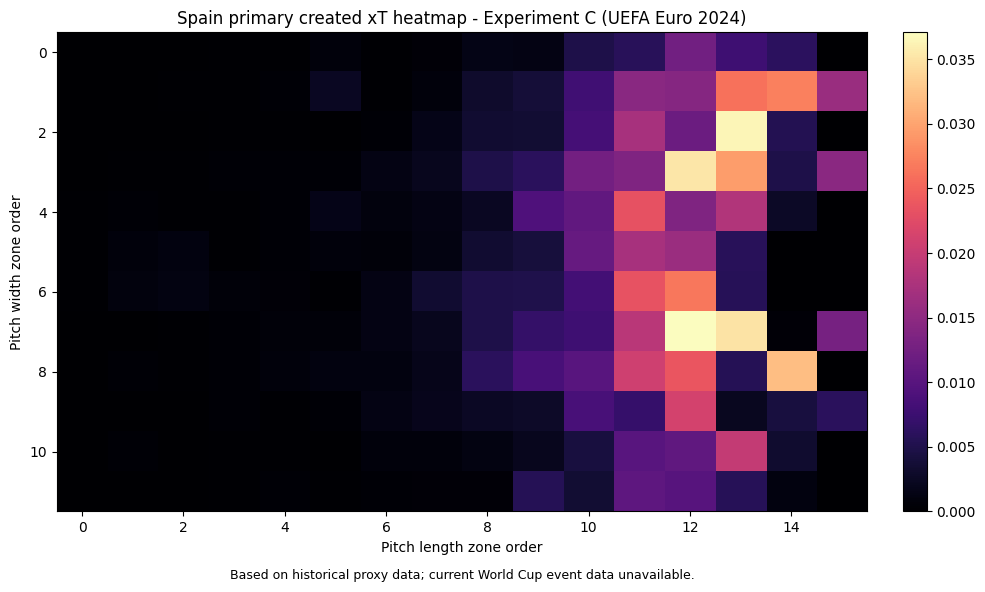

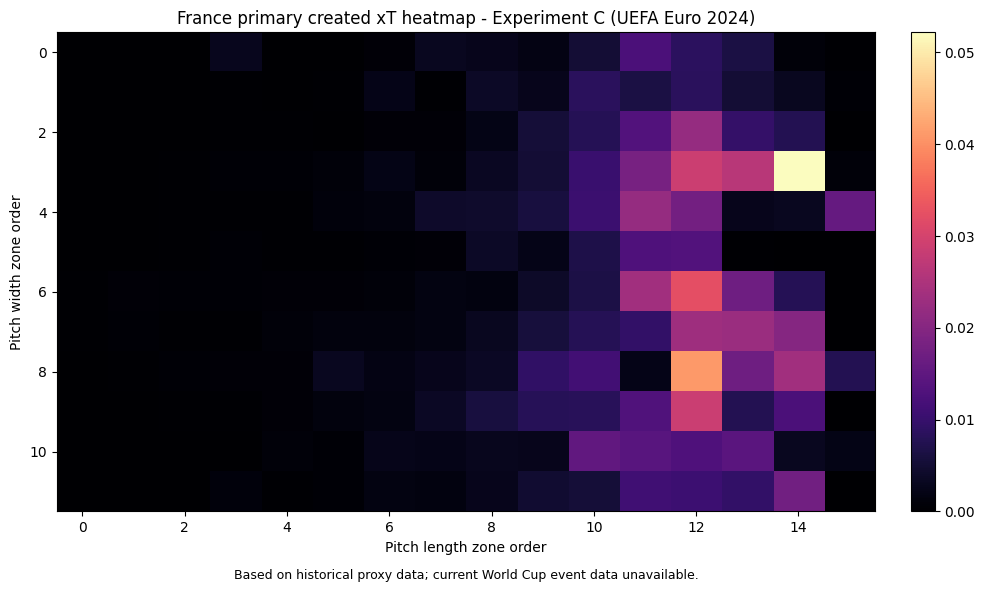

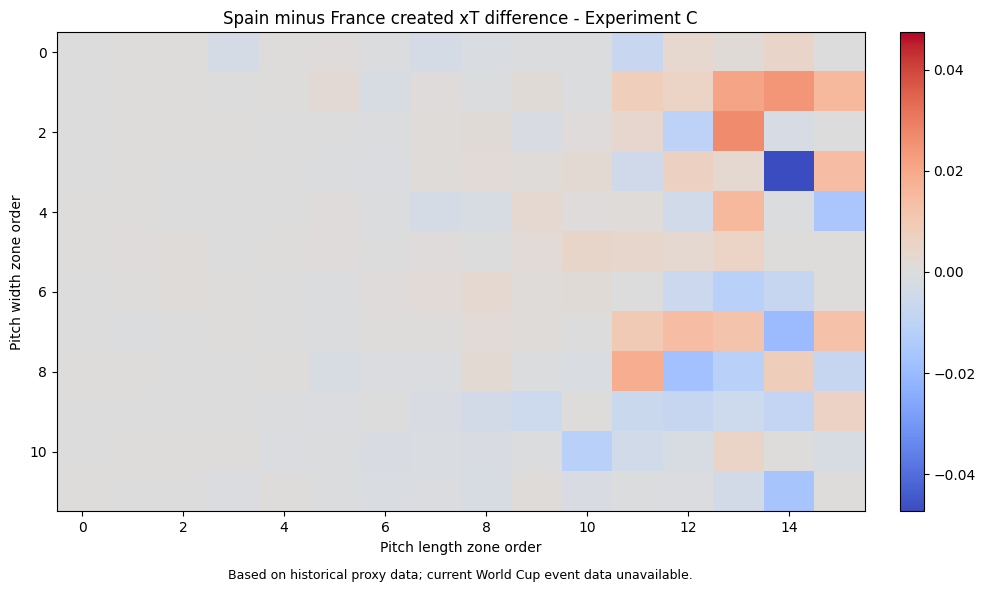

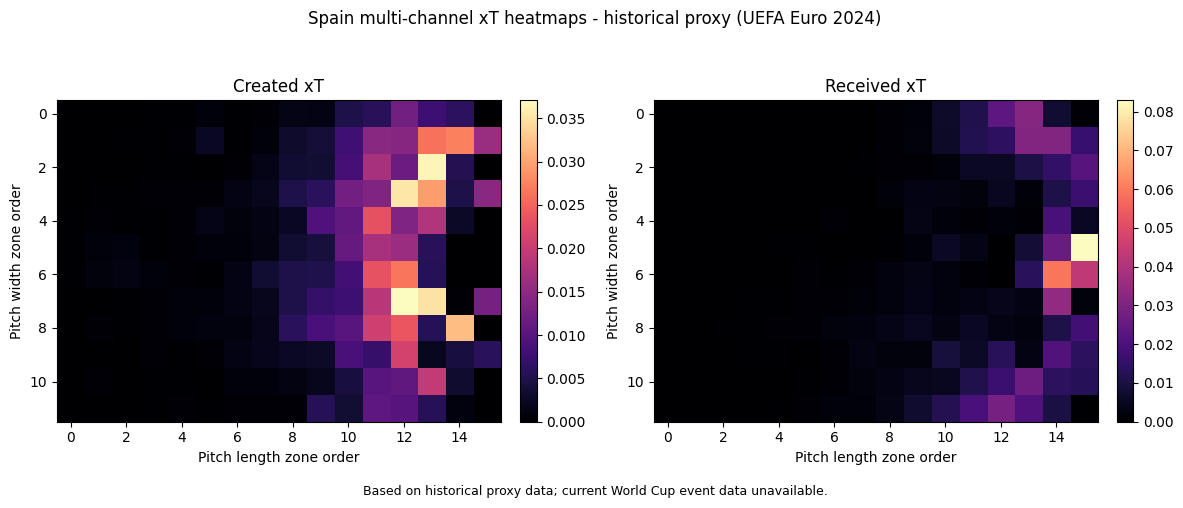

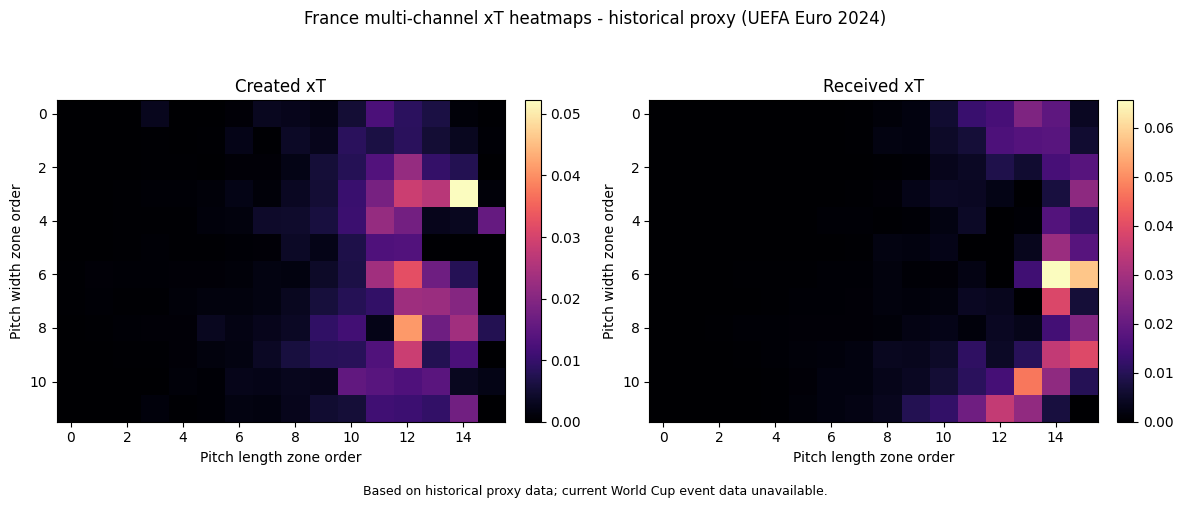

Generated heatmap outputs:
- outputs\spain_france_prediction\spain_primary_xt_heatmap.png
- outputs\spain_france_prediction\france_primary_xt_heatmap.png
- outputs\spain_france_prediction\spain_minus_france_xt_difference.png
- outputs\spain_france_prediction\spain_multichannel_xt_heatmaps.png
- outputs\spain_france_prediction\france_multichannel_xt_heatmaps.png


In [8]:
def values_to_grid(values):
    values = np.asarray(values, dtype=float)
    return values.reshape(GRID_SHAPE) if len(values) == GRID_SHAPE[0] * GRID_SHAPE[1] else None

def plot_heatmap_grid(grid, title, output_path, cmap="viridis", center_zero=False):
    if grid is None:
        print(f"Skipping {output_path}: incompatible vector length.")
        return False
    fig, ax = plt.subplots(figsize=(10, 6))
    if center_zero:
        vmax = np.nanmax(np.abs(grid)) if np.isfinite(grid).any() else 1
        im = ax.imshow(grid, cmap=cmap, aspect="auto", vmin=-vmax, vmax=vmax)
    else:
        im = ax.imshow(grid, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Pitch length zone order")
    ax.set_ylabel("Pitch width zone order")
    ax.text(0.5, -0.12, "Based on historical proxy data; current World Cup event data unavailable.", transform=ax.transAxes, ha="center", va="top", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return True

figure_outputs = []
if primary_experiment in spain_reference_rows and primary_experiment in france_reference_rows:
    spain_row = spain_reference_rows[primary_experiment]
    france_row = france_reference_rows[primary_experiment]
    for team, row, output_name in [("Spain", spain_row, "spain_primary_xt_heatmap.png"), ("France", france_row, "france_primary_xt_heatmap.png")]:
        values, _ = vector_for_prefix(row, "created_z")
        path = OUTPUT_DIR / output_name
        title = f"{team} primary created xT heatmap - Experiment {primary_experiment} ({row.get('competition_name', '')} {row.get('season_name', '')})"
        if plot_heatmap_grid(values_to_grid(values), title, path, cmap="magma"):
            figure_outputs.append(path)
    spain_values, _ = vector_for_prefix(spain_row, "created_z")
    france_values, _ = vector_for_prefix(france_row, "created_z")
    if len(spain_values) == len(france_values) and len(spain_values):
        path = OUTPUT_DIR / "spain_minus_france_xt_difference.png"
        if plot_heatmap_grid(values_to_grid(spain_values - france_values), f"Spain minus France created xT difference - Experiment {primary_experiment}", path, cmap="coolwarm", center_zero=True):
            figure_outputs.append(path)
    if primary_experiment == "C":
        for team, row, output_name in [("Spain", spain_row, "spain_multichannel_xt_heatmaps.png"), ("France", france_row, "france_multichannel_xt_heatmaps.png")]:
            prefixes = [p for p in ["created_z", "received_z", "pass_created_z", "carry_created_z", "action_count_z"] if len(vector_for_prefix(row, p)[0])]
            if prefixes:
                fig, axes = plt.subplots(1, len(prefixes), figsize=(6 * len(prefixes), 5), squeeze=False)
                for ax, prefix in zip(axes[0], prefixes):
                    values, _ = vector_for_prefix(row, prefix)
                    im = ax.imshow(values_to_grid(values), cmap="magma", aspect="auto")
                    ax.set_title(CHANNEL_LABELS.get(prefix, prefix))
                    ax.set_xlabel("Pitch length zone order")
                    ax.set_ylabel("Pitch width zone order")
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                fig.suptitle(f"{team} multi-channel xT heatmaps - historical proxy ({row.get('competition_name', '')} {row.get('season_name', '')})")
                fig.text(0.5, 0.01, "Based on historical proxy data; current World Cup event data unavailable.", ha="center", fontsize=9)
                fig.tight_layout(rect=[0, 0.04, 1, 0.94])
                path = OUTPUT_DIR / output_name
                fig.savefig(path, dpi=160, bbox_inches="tight")
                plt.show()
                figure_outputs.append(path)
print("Generated heatmap outputs:")
for path in figure_outputs:
    print(f"- {path}")

## Historical Cluster Matchup Analysis

The notebook attempts to use only local files to load or construct a primary-experiment cluster-versus-cluster matchup table. If match outcomes cannot be linked to clusters, this module is skipped rather than inventing statistics.

In [9]:
cluster_matchup_table = pd.DataFrame()
cluster_matchup_baseline = pd.DataFrame()
cluster_component_available = False
cluster_component_value = np.nan
cluster_matchup_sample_size = 0
cluster_matchup_note = "Historical match outcomes could not be linked to primary xT clusters."

ready_cluster_matchup_candidates = project_file_inventory[
    project_file_inventory["path"].str.contains("cluster", case=False, na=False)
    & project_file_inventory["path"].str.contains("matchup", case=False, na=False)
]
print("Ready-made cluster matchup candidates:")
display(ready_cluster_matchup_candidates)

match_metadata_path = Path("outputs/match_metadata.csv")
if match_metadata_path.exists():
    match_metadata = load_csv(match_metadata_path, inspect=True)
    score_cols = detect_columns(match_metadata, SCORE_COL_CANDIDATES)
    if {"home_team_name", "away_team_name"}.issubset(match_metadata.columns) and len(score_cols) >= 2:
        print("A cluster matchup table can be attempted because team names and score columns are present.")
    else:
        print("Skipping constructed cluster matchup table: match metadata lacks score/result columns.")
else:
    print("No match metadata file found.")

if not cluster_matchup_table.empty:
    cluster_matchup_table.to_csv(OUTPUT_DIR / "historical_cluster_matchup_table.csv", index=False)
    cluster_matchup_baseline.to_csv(OUTPUT_DIR / "spain_france_cluster_matchup_baseline.csv", index=False)
else:
    print("[Skipped] Historical cluster matchup analysis: no reliable local cluster-outcome linkage available.")
print(cluster_matchup_note)

Ready-made cluster matchup candidates:


,category,path,suffix,size_bytes


CSV loaded: outputs\match_metadata.csv
Shape: (3961, 11)
Columns:
['competition_id', 'competition_name', 'country_name', 'season_id', 'season_name', 'match_id', 'match_date', 'home_team_id', 'home_team_name', 'away_team_id', 'away_team_name']
Likely team columns: ['home_team_name', 'away_team_name', 'home_team_id', 'away_team_id']
Likely season columns: ['season_name', 'season_id']
Likely competition columns: ['competition_name', 'competition_id', 'country_name']
Likely cluster columns: []
Likely feature columns, first 12: []
Likely result columns: []
Likely score columns: []
Likely formation columns: []


,competition_id,competition_name,country_name,season_id,season_name,match_id,match_date,home_team_id,home_team_name,away_team_id,away_team_name
0,9,1. Bundesliga,Germany,281,2023/2024,3895292,2024-04-06,190,Union Berlin,904,Bayer Leverkusen
1,9,1. Bundesliga,Germany,281,2023/2024,3895320,2024-04-27,904,Bayer Leverkusen,174,VfB Stuttgart
2,9,1. Bundesliga,Germany,281,2023/2024,3895158,2023-12-03,904,Bayer Leverkusen,180,Borussia Dortmund
3,9,1. Bundesliga,Germany,281,2023/2024,3895107,2023-10-08,904,Bayer Leverkusen,186,FC Köln
4,9,1. Bundesliga,Germany,281,2023/2024,3895340,2024-05-12,868,Bochum,904,Bayer Leverkusen


Skipping constructed cluster matchup table: match metadata lacks score/result columns.
[Skipped] Historical cluster matchup analysis: no reliable local cluster-outcome linkage available.
Historical match outcomes could not be linked to primary xT clusters.


## Tactical Statistics and Formation Scenarios

The tactical model is separate from the xT model. This section searches local tactical files, inspects usable CSVs, and creates user-configurable formation scenarios when current confirmed formations are unavailable.

In [10]:
TACTICAL_SEARCH_TERMS = ["formation", "tactical", "matchup", "counter", "win_rate", "style", "strategy", "statistics"]
tactical_candidates = project_file_inventory[project_file_inventory["path"].str.contains("|".join(TACTICAL_SEARCH_TERMS), case=False, na=False)].copy()
display(tactical_candidates)

tactical_tables = {}
for path_text in tactical_candidates["path"]:
    path = PROJECT_ROOT / path_text
    if path.suffix.lower() == ".csv" and path.exists():
        tactical_tables[path_text] = load_csv(path, inspect=True)

formation_summary_path = Path("outputs/formation_matchup_summary.csv")
formation_rows_path = Path("outputs/formation_match_rows.csv")
formation_summary = tactical_tables.get(str(formation_summary_path))
if formation_summary is None and formation_summary_path.exists():
    formation_summary = load_csv(formation_summary_path, inspect=True)
formation_rows = tactical_tables.get(str(formation_rows_path))
if formation_rows is None and formation_rows_path.exists():
    formation_rows = load_csv(formation_rows_path, inspect=True)

FORMATION_SCENARIOS = {"Spain": ["4-3-3", "4-2-3-1"], "France": ["4-2-3-1", "4-3-3", "4-4-2"]}
formation_scenario_source = "User-configurable tactical scenarios"

def normalize_formation(value):
    return "" if pd.isna(value) else re.sub(r"[^0-9]", "", str(value))

def format_formation(value):
    text = str(value)
    if "-" in text:
        return text
    digits = normalize_formation(text)
    if len(digits) == 3:
        return "-".join(digits)
    if len(digits) == 4:
        return f"{digits[0]}-{digits[1]}-{digits[2]}-{digits[3]}"
    return text

def team_formation_frequencies(rows, team):
    if rows is None or rows.empty or "team" not in rows.columns or "formation" not in rows.columns:
        return pd.DataFrame()
    matches = rows[rows["team"].map(normalize_name) == normalize_name(team)].copy()
    if matches.empty:
        return pd.DataFrame()
    counts = matches["formation"].value_counts().reset_index()
    counts.columns = ["formation", "usage_count"]
    counts["usage_percentage"] = counts["usage_count"] / counts["usage_count"].sum()
    return counts

for team in ["Spain", "France"]:
    freqs = team_formation_frequencies(formation_rows, team)
    if freqs.empty:
        print(f"No historical formation frequencies found for {team}; using configurable tactical scenarios.")
    else:
        display(freqs)
        FORMATION_SCENARIOS[team] = [format_formation(v) for v in freqs.head(2)["formation"].tolist()]
        formation_scenario_source = "Local tactical model formation frequencies"
print(FORMATION_SCENARIOS)
print(formation_scenario_source)

,category,path,suffix,size_bytes
0,formation statistics; previously trained predi...,outputs\spain_france_prediction\spain_france_f...,.csv,1265
1,formation statistics; tactical statistics,outputs\formation_matchup_summary.csv,.csv,13349
3,match metadata; match results; formation stati...,outputs\formation_match_rows.csv,.csv,730831
23,previously trained prediction models,outputs\spain_france_prediction\spain_france_s...,.csv,747
24,previously trained prediction models,outputs\spain_france_prediction\spain_france_s...,.csv,80988
26,previously trained prediction models,outputs\spain_france_prediction\spain_france_x...,.csv,1750
28,tactical statistics,football-match-data-analysis-tactical-insights...,.ipynb,334697
29,tactical statistics,outputs\example_strategy_report_433_vs_442.txt,.txt,545
30,tactical statistics,outputs\top_favorable_matchups.csv,.csv,7192
31,tactical statistics,outputs\top_unfavorable_matchups.csv,.csv,7441


CSV loaded: d:\UIUC\Projects\World Cup 2026\outputs\spain_france_prediction\spain_france_formation_scenarios.csv
Shape: (4, 13)
Columns:
['sample_size', 'spain_side_win_rate', 'draw_rate', 'france_side_win_rate', 'average_goal_difference', 'points_per_game', 'data_source_file', 'confidence_note', 'fallback_level', 'spain_formation', 'france_formation', 'scenario_label', 'scenario_source']
Likely team columns: []
Likely season columns: []
Likely competition columns: []
Likely cluster columns: []
Likely feature columns, first 12: ['sample_size']
Likely result columns: ['draw_rate']
Likely score columns: []
Likely formation columns: ['spain_formation', 'france_formation']


,sample_size,spain_side_win_rate,draw_rate,france_side_win_rate,average_goal_difference,points_per_game,data_source_file,confidence_note,fallback_level,spain_formation,france_formation,scenario_label,scenario_source
0,611,0.536825,0.191489,0.271686,0.783961,1.801964,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-3-3,4-2-3-1,Spain 4-3-3 vs France 4-2-3-1,Local tactical model formation frequencies
1,316,0.389241,0.221519,0.389241,0.000000,1.389241,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-3-3,4-3-3,Spain 4-3-3 vs France 4-3-3,Local tactical model formation frequencies
2,814,0.373464,0.253071,0.373464,0.000000,1.373464,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-2-3-1,4-2-3-1,Spain 4-2-3-1 vs France 4-2-3-1,Local tactical model formation frequencies
3,611,0.271686,0.191489,0.536825,-0.783961,1.006547,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-2-3-1,4-3-3,Spain 4-2-3-1 vs France 4-3-3,Local tactical model formation frequencies


CSV loaded: d:\UIUC\Projects\World Cup 2026\outputs\formation_matchup_summary.csv
Shape: (105, 12)
Columns:
['formation', 'opponent_formation', 'games', 'wins', 'draws', 'losses', 'win_rate', 'draw_rate', 'loss_rate', 'points_per_game', 'goal_diff_per_game', 'smoothed_win_rate']
Likely team columns: []
Likely season columns: []
Likely competition columns: []
Likely cluster columns: []
Likely feature columns, first 12: ['formation', 'opponent_formation', 'games']
Likely result columns: ['win_rate', 'draw_rate', 'loss_rate', 'wins', 'draws', 'losses']
Likely score columns: []
Likely formation columns: ['formation', 'opponent_formation']


,formation,opponent_formation,games,wins,draws,losses,win_rate,draw_rate,loss_rate,points_per_game,goal_diff_per_game,smoothed_win_rate
0,3412,343,10,5,2,3,0.500000,0.200000,0.300000,1.700000,0.600000,0.444215
1,3412,352,24,11,2,11,0.458333,0.083333,0.458333,1.458333,-0.250000,0.437773
2,3412,41212,12,6,2,4,0.500000,0.166667,0.333333,1.666667,0.000000,0.449286
3,3412,4141,15,7,5,3,0.466667,0.333333,0.200000,1.733333,0.800000,0.435372
4,3412,4231,36,7,10,19,0.194444,0.277778,0.527778,0.861111,-0.611111,0.236615


...

CSV loaded: d:\UIUC\Projects\World Cup 2026\outputs\spain_france_prediction\spain_france_tactical_scenario_predictions.csv
Shape: (4, 21)
Columns:
['spain_formation', 'france_formation', 'strength_component', 'cluster_component', 'formation_component', 'supervised_component', 'component_weights_used', 'final_relative_score', 'spain_win_90_probability', 'draw_90_probability', 'france_win_90_probability', 'spain_conditional_advance_after_draw', 'france_conditional_advance_after_draw', 'spain_advance_probability', 'france_advance_probability', 'predicted_advancing_team', 'tactical_sample_size', 'confidence_note', 'fallback_level', 'data_source_file', 'scenario_source']
Likely team columns: ['predicted_advancing_team']
Likely season columns: []
Likely competition columns: []
Likely cluster columns: ['cluster_component']
Likely feature columns, first 12: ['strength_component', 'formation_component', 'supervised_component', 'final_relative_score', 'spain_advance_probability', 'france_advance

,spain_formation,france_formation,strength_component,cluster_component,formation_component,supervised_component,component_weights_used,final_relative_score,spain_win_90_probability,draw_90_probability,...,spain_conditional_advance_after_draw,france_conditional_advance_after_draw,spain_advance_probability,france_advance_probability,predicted_advancing_team,tactical_sample_size,confidence_note,fallback_level,data_source_file,scenario_source
0,4-3-3,4-2-3-1,0.4,NaN,0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.355046,0.371038,0.305065,...,0.544265,0.455735,0.537075,0.462925,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
1,4-3-3,4-3-3,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,316,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
2,4-2-3-1,4-2-3-1,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,814,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
3,4-2-3-1,4-3-3,0.4,NaN,-0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.178287,0.355531,0.307531,...,0.522271,0.477729,0.516145,0.483855,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies


,formation,usage_count,usage_percentage
0,433,14,0.666667
1,4231,6,0.285714
2,4141,1,0.047619


,formation,usage_count,usage_percentage
0,4231,13,0.52
1,433,7,0.28
2,442,2,0.08
3,3412,1,0.04
4,4411,1,0.04
5,41212,1,0.04


{'Spain': ['4-3-3', '4-2-3-1'], 'France': ['4-2-3-1', '4-3-3']}
Local tactical model formation frequencies


## Formation and Tactical Matchup Scenarios

Exact formation matchups are preferred. Reverse matchups are inverted when available. If necessary, the notebook falls back to formation-level or global averages, and labels the fallback.

In [11]:
def global_formation_average(summary):
    if summary is None or summary.empty:
        return {"win_rate": np.nan, "draw_rate": np.nan, "loss_rate": np.nan, "points_per_game": np.nan, "goal_diff_per_game": np.nan, "games": 0}
    return {
        "win_rate": pd.to_numeric(summary.get("win_rate"), errors="coerce").mean(),
        "draw_rate": pd.to_numeric(summary.get("draw_rate"), errors="coerce").mean(),
        "loss_rate": pd.to_numeric(summary.get("loss_rate"), errors="coerce").mean(),
        "points_per_game": pd.to_numeric(summary.get("points_per_game"), errors="coerce").mean(),
        "goal_diff_per_game": pd.to_numeric(summary.get("goal_diff_per_game"), errors="coerce").mean(),
        "games": int(pd.to_numeric(summary.get("games"), errors="coerce").sum()) if "games" in summary.columns else 0,
    }

def retrieve_formation_matchup(summary, spain_form, france_form):
    if summary is None or summary.empty:
        return {"sample_size": 0, "spain_side_win_rate": np.nan, "draw_rate": np.nan, "france_side_win_rate": np.nan, "average_goal_difference": np.nan, "points_per_game": np.nan, "data_source_file": "none", "confidence_note": "No tactical statistics table available; no tactical advantage assigned.", "fallback_level": "no tactical data"}
    table = summary.copy()
    table["_formation_norm"] = table["formation"].map(normalize_formation)
    table["_opponent_formation_norm"] = table["opponent_formation"].map(normalize_formation)
    spain_norm = normalize_formation(spain_form)
    france_norm = normalize_formation(france_form)
    exact = table[(table["_formation_norm"] == spain_norm) & (table["_opponent_formation_norm"] == france_norm)]
    if not exact.empty:
        row = exact.sort_values("games", ascending=False).iloc[0]
        return {"sample_size": int(row.get("games", 0)), "spain_side_win_rate": float(row.get("win_rate", np.nan)), "draw_rate": float(row.get("draw_rate", np.nan)), "france_side_win_rate": float(row.get("loss_rate", np.nan)), "average_goal_difference": float(row.get("goal_diff_per_game", np.nan)), "points_per_game": float(row.get("points_per_game", np.nan)), "data_source_file": str(formation_summary_path), "confidence_note": "Exact formation matchup found." if row.get("games", 0) >= MIN_FORMATION_MATCHUP_SAMPLE else "Exact formation matchup found but sample is small.", "fallback_level": "exact matchup"}
    reverse = table[(table["_formation_norm"] == france_norm) & (table["_opponent_formation_norm"] == spain_norm)]
    if not reverse.empty:
        row = reverse.sort_values("games", ascending=False).iloc[0]
        return {"sample_size": int(row.get("games", 0)), "spain_side_win_rate": float(row.get("loss_rate", np.nan)), "draw_rate": float(row.get("draw_rate", np.nan)), "france_side_win_rate": float(row.get("win_rate", np.nan)), "average_goal_difference": -float(row.get("goal_diff_per_game", np.nan)), "points_per_game": float(3 * row.get("loss_rate", np.nan) + row.get("draw_rate", np.nan)), "data_source_file": str(formation_summary_path), "confidence_note": "Reverse formation matchup found and outcomes inverted." if row.get("games", 0) >= MIN_FORMATION_MATCHUP_SAMPLE else "Reverse matchup found but sample is small.", "fallback_level": "reverse matchup inverted"}
    form_rows = table[table["_formation_norm"] == spain_norm]
    if not form_rows.empty:
        weights = pd.to_numeric(form_rows["games"], errors="coerce").fillna(1)
        win = np.average(pd.to_numeric(form_rows["win_rate"], errors="coerce"), weights=weights)
        draw = np.average(pd.to_numeric(form_rows["draw_rate"], errors="coerce"), weights=weights)
        loss = np.average(pd.to_numeric(form_rows["loss_rate"], errors="coerce"), weights=weights)
        gd = np.average(pd.to_numeric(form_rows["goal_diff_per_game"], errors="coerce"), weights=weights)
        return {"sample_size": int(weights.sum()), "spain_side_win_rate": float(win), "draw_rate": float(draw), "france_side_win_rate": float(loss), "average_goal_difference": float(gd), "points_per_game": float(3 * win + draw), "data_source_file": str(formation_summary_path), "confidence_note": "Fallback to Spain formation overall historical performance.", "fallback_level": "formation overall fallback"}
    avg = global_formation_average(table)
    return {"sample_size": avg["games"], "spain_side_win_rate": avg["win_rate"], "draw_rate": avg["draw_rate"], "france_side_win_rate": avg["loss_rate"], "average_goal_difference": avg["goal_diff_per_game"], "points_per_game": avg["points_per_game"], "data_source_file": str(formation_summary_path), "confidence_note": "Fallback to global formation matchup average; no specific tactical advantage assigned.", "fallback_level": "global average fallback"}

formation_rows_out = []
for spain_form in FORMATION_SCENARIOS["Spain"]:
    for france_form in FORMATION_SCENARIOS["France"]:
        stats = retrieve_formation_matchup(formation_summary, spain_form, france_form)
        stats.update({"spain_formation": spain_form, "france_formation": france_form, "scenario_label": f"Spain {spain_form} vs France {france_form}", "scenario_source": formation_scenario_source})
        formation_rows_out.append(stats)
formation_scenarios = pd.DataFrame(formation_rows_out)
formation_scenarios.to_csv(OUTPUT_DIR / "spain_france_formation_scenarios.csv", index=False)
display(formation_scenarios)

,sample_size,spain_side_win_rate,draw_rate,france_side_win_rate,average_goal_difference,points_per_game,data_source_file,confidence_note,fallback_level,spain_formation,france_formation,scenario_label,scenario_source
0,611,0.536825,0.191489,0.271686,0.783961,1.801964,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-3-3,4-2-3-1,Spain 4-3-3 vs France 4-2-3-1,Local tactical model formation frequencies
1,316,0.389241,0.221519,0.389241,0.000000,1.389241,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-3-3,4-3-3,Spain 4-3-3 vs France 4-3-3,Local tactical model formation frequencies
2,814,0.373464,0.253071,0.373464,0.000000,1.373464,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-2-3-1,4-2-3-1,Spain 4-2-3-1 vs France 4-2-3-1,Local tactical model formation frequencies
3,611,0.271686,0.191489,0.536825,-0.783961,1.006547,outputs\formation_matchup_summary.csv,Exact formation matchup found.,exact matchup,4-2-3-1,4-3-3,Spain 4-2-3-1 vs France 4-3-3,Local tactical model formation frequencies


## Optional Existing Supervised Prediction Model

The notebook searches for ready-to-use supervised match-prediction artifacts. It does not train a new complicated model solely for this proof of concept.

In [12]:
supervised_candidates = project_file_inventory[project_file_inventory["path"].str.contains("prediction|model|logistic|random_forest|xgboost|calibration|target_supervised", case=False, na=False)].copy()
display(supervised_candidates)
supervised_component_available = False
supervised_component_value = np.nan
supervised_note = "No ready-to-use compatible supervised match prediction model found; skipped."
print(supervised_note)

,category,path,suffix,size_bytes
0,formation statistics; previously trained predi...,outputs\spain_france_prediction\spain_france_f...,.csv,1265
18,previously trained prediction models,outputs\spain_france_prediction\final_spain_fr...,.csv,1172
19,previously trained prediction models,outputs\spain_france_prediction\prediction_unc...,.csv,324
20,previously trained prediction models,outputs\spain_france_prediction\project_file_i...,.csv,7676
21,previously trained prediction models,outputs\spain_france_prediction\spain_france_c...,.csv,2357
22,previously trained prediction models,outputs\spain_france_prediction\spain_france_s...,.csv,1174
23,previously trained prediction models,outputs\spain_france_prediction\spain_france_s...,.csv,747
24,previously trained prediction models,outputs\spain_france_prediction\spain_france_s...,.csv,80988
25,previously trained prediction models,outputs\spain_france_prediction\spain_france_x...,.csv,152090
26,previously trained prediction models,outputs\spain_france_prediction\spain_france_x...,.csv,1750


No ready-to-use compatible supervised match prediction model found; skipped.


## Historical Team Strength Prior

The preferred inputs are historical match results, average goal difference, win rate, total xT created and received, or existing strength scores. When result data is unavailable, the notebook uses available historical proxy xT components. Manual priors are only used if no local components can be calculated.

In [13]:
MANUAL_STRENGTH_PRIORS = {"Spain": 0.80, "France": 0.83}

def safe_float(value):
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan

def minmax_two_values(a, b):
    values = np.array([a, b], dtype=float)
    if np.any(~np.isfinite(values)):
        return np.nan, np.nan
    if np.isclose(values.max(), values.min()):
        return 0.5, 0.5
    scaled = (values - values.min()) / (values.max() - values.min())
    return float(scaled[0]), float(scaled[1])

strength_records = []
if primary_experiment in spain_reference_rows and primary_experiment in france_reference_rows:
    spain_row = spain_reference_rows[primary_experiment]
    france_row = france_reference_rows[primary_experiment]
    components = []
    sp_total = safe_float(spain_row.get("total_positive_xT", np.nan))
    fr_total = safe_float(france_row.get("total_positive_xT", np.nan))
    sp_scaled, fr_scaled = minmax_two_values(sp_total, fr_total)
    if pd.notna(sp_scaled):
        components.append(("normalized_total_positive_xT", sp_scaled, fr_scaled, 0.50))
    sp_created, _ = vector_for_prefix(spain_row, "created_z")
    fr_created, _ = vector_for_prefix(france_row, "created_z")
    sp_received, _ = vector_for_prefix(spain_row, "received_z")
    fr_received, _ = vector_for_prefix(france_row, "received_z")
    if len(sp_created) and len(fr_created) and len(sp_received) and len(fr_received):
        sp_bal = float(np.nansum(sp_created) - np.nansum(sp_received))
        fr_bal = float(np.nansum(fr_created) - np.nansum(fr_received))
        sp_scaled, fr_scaled = minmax_two_values(sp_bal, fr_bal)
        if pd.notna(sp_scaled):
            components.append(("normalized_created_minus_received_xT", sp_scaled, fr_scaled, 0.30))
    sp_pass = safe_float(spain_row.get("pass_xT_share", np.nan))
    fr_pass = safe_float(france_row.get("pass_xT_share", np.nan))
    sp_scaled, fr_scaled = minmax_two_values(sp_pass, fr_pass)
    if pd.notna(sp_scaled):
        components.append(("normalized_pass_xT_share", sp_scaled, fr_scaled, 0.20))
    if components:
        total_weight = sum(w for _, _, _, w in components)
        spain_strength = sum(sp * w for _, sp, _, w in components) / total_weight
        france_strength = sum(fr * w for _, _, fr, w in components) / total_weight
        for component, sp, fr, weight in components:
            strength_records.extend([
                {"team": "Spain", "component": component, "component_value": sp, "component_weight": weight / total_weight, "source": "local xT historical proxy"},
                {"team": "France", "component": component, "component_value": fr, "component_weight": weight / total_weight, "source": "local xT historical proxy"},
            ])
        strength_source_note = "Calculated from available historical proxy xT components; weights renormalized over available components."
    else:
        spain_strength = MANUAL_STRENGTH_PRIORS["Spain"]
        france_strength = MANUAL_STRENGTH_PRIORS["France"]
        strength_source_note = "Manually configured demonstration strength prior; not a current FIFA strength rating."
else:
    spain_strength = MANUAL_STRENGTH_PRIORS["Spain"]
    france_strength = MANUAL_STRENGTH_PRIORS["France"]
    strength_source_note = "Manually configured demonstration strength prior; not a current FIFA strength rating."

if not strength_records:
    strength_records = [
        {"team": "Spain", "component": "manual_strength_prior", "component_value": spain_strength, "component_weight": 1.0, "source": "Manually configured demonstration strength prior"},
        {"team": "France", "component": "manual_strength_prior", "component_value": france_strength, "component_weight": 1.0, "source": "Manually configured demonstration strength prior"},
    ]

strength_prior = pd.DataFrame(strength_records)
strength_scores = pd.DataFrame([
    {"team": "Spain", "strength_score": spain_strength, "source_note": strength_source_note},
    {"team": "France", "strength_score": france_strength, "source_note": strength_source_note},
])
strength_prior = strength_prior.merge(strength_scores, on="team", how="left")
strength_prior.to_csv(OUTPUT_DIR / "spain_france_strength_prior.csv", index=False)
display(strength_prior)
print(strength_source_note)

,team,component,component_value,component_weight,source,strength_score,source_note
0,Spain,normalized_total_positive_xT,1.0,0.5,local xT historical proxy,0.7,Calculated from available historical proxy xT ...
1,France,normalized_total_positive_xT,0.0,0.5,local xT historical proxy,0.3,Calculated from available historical proxy xT ...
2,Spain,normalized_created_minus_received_xT,0.0,0.3,local xT historical proxy,0.7,Calculated from available historical proxy xT ...
3,France,normalized_created_minus_received_xT,1.0,0.3,local xT historical proxy,0.3,Calculated from available historical proxy xT ...
4,Spain,normalized_pass_xT_share,1.0,0.2,local xT historical proxy,0.7,Calculated from available historical proxy xT ...
5,France,normalized_pass_xT_share,0.0,0.2,local xT historical proxy,0.3,Calculated from available historical proxy xT ...


Calculated from available historical proxy xT components; weights renormalized over available components.


## Transparent Rule-Based Prediction

The final score combines available components. Unavailable components are removed and the remaining weights are renormalized. The probabilities are demonstration outputs and the weights are not statistically optimized.

In [14]:
PREDICTION_WEIGHTS = {"strength": 0.50, "cluster_matchup": 0.25, "formation_matchup": 0.25}
PREDICTION_WEIGHTS_WITH_SUPERVISED = {"strength": 0.35, "cluster_matchup": 0.20, "formation_matchup": 0.20, "supervised_model": 0.25}
BASE_90_MINUTE_PROBABILITIES = {"spain_win": 0.34, "draw": 0.31, "france_win": 0.35}

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def normalize_probability_dict(prob_dict):
    cleaned = {k: max(0.0, float(v)) for k, v in prob_dict.items()}
    total = sum(cleaned.values())
    return {k: v / total for k, v in cleaned.items()} if total > 0 else {k: 1 / len(cleaned) for k in cleaned}

def component_weights(component_values):
    base = PREDICTION_WEIGHTS_WITH_SUPERVISED if supervised_component_available else PREDICTION_WEIGHTS
    available = {name: base[name] for name, value in component_values.items() if pd.notna(value) and name in base}
    total = sum(available.values())
    return {name: weight / total for name, weight in available.items()} if total > 0 else {}

def calculate_prediction_for_formation(spain_form, france_form, formation_stats):
    strength_advantage = float(spain_strength - france_strength)
    cluster_advantage = cluster_component_value if cluster_component_available else np.nan
    formation_advantage = np.nan
    if pd.notna(formation_stats.get("spain_side_win_rate", np.nan)) and pd.notna(formation_stats.get("france_side_win_rate", np.nan)):
        formation_advantage = float(formation_stats["spain_side_win_rate"] - formation_stats["france_side_win_rate"])
    supervised_advantage = supervised_component_value if supervised_component_available else np.nan
    components = {"strength": strength_advantage, "cluster_matchup": cluster_advantage, "formation_matchup": formation_advantage, "supervised_model": supervised_advantage}
    weights = component_weights(components)
    final_relative_score = sum(components[name] * weights[name] for name in weights)
    raw_90 = {
        "spain_win": BASE_90_MINUTE_PROBABILITIES["spain_win"] + 0.08 * final_relative_score,
        "draw": max(0.20, BASE_90_MINUTE_PROBABILITIES["draw"] - 0.02 * abs(final_relative_score)),
        "france_win": BASE_90_MINUTE_PROBABILITIES["france_win"] - 0.08 * final_relative_score,
    }
    probs_90 = normalize_probability_dict(raw_90)
    spain_cond_after_draw = float(sigmoid(0.5 * final_relative_score))
    france_cond_after_draw = 1 - spain_cond_after_draw
    adv = normalize_probability_dict({
        "Spain": probs_90["spain_win"] + probs_90["draw"] * spain_cond_after_draw,
        "France": probs_90["france_win"] + probs_90["draw"] * france_cond_after_draw,
    })
    return {
        "spain_formation": spain_form,
        "france_formation": france_form,
        "strength_component": strength_advantage,
        "cluster_component": cluster_advantage,
        "formation_component": formation_advantage,
        "supervised_component": supervised_advantage,
        "component_weights_used": json.dumps(weights, sort_keys=True),
        "final_relative_score": final_relative_score,
        "spain_win_90_probability": probs_90["spain_win"],
        "draw_90_probability": probs_90["draw"],
        "france_win_90_probability": probs_90["france_win"],
        "spain_conditional_advance_after_draw": spain_cond_after_draw,
        "france_conditional_advance_after_draw": france_cond_after_draw,
        "spain_advance_probability": adv["Spain"],
        "france_advance_probability": adv["France"],
        "predicted_advancing_team": "Spain" if adv["Spain"] >= adv["France"] else "France",
    }

scenario_prediction_records = []
for _, scenario in formation_scenarios.iterrows():
    pred = calculate_prediction_for_formation(scenario["spain_formation"], scenario["france_formation"], scenario)
    for col in ["sample_size", "confidence_note", "fallback_level", "data_source_file", "scenario_source"]:
        pred[col if col != "sample_size" else "tactical_sample_size"] = scenario.get(col, np.nan)
    scenario_prediction_records.append(pred)
scenario_predictions = pd.DataFrame(scenario_prediction_records).sort_values("spain_advance_probability", ascending=False).reset_index(drop=True)
scenario_predictions.to_csv(OUTPUT_DIR / "spain_france_tactical_scenario_predictions.csv", index=False)
display(scenario_predictions)

baseline_spain_form = FORMATION_SCENARIOS["Spain"][0]
baseline_france_form = FORMATION_SCENARIOS["France"][0]
baseline_prediction = scenario_predictions[(scenario_predictions["spain_formation"] == baseline_spain_form) & (scenario_predictions["france_formation"] == baseline_france_form)]
baseline_prediction = (baseline_prediction if not baseline_prediction.empty else scenario_predictions.head(1)).iloc[0]
print("Final component weights used:", baseline_prediction["component_weights_used"])
for col in ["strength_component", "cluster_component", "formation_component", "supervised_component", "final_relative_score"]:
    print(f"{col}: {baseline_prediction[col]}")
assert np.isclose(baseline_prediction["spain_win_90_probability"] + baseline_prediction["draw_90_probability"] + baseline_prediction["france_win_90_probability"], 1.0)
assert np.isclose(baseline_prediction["spain_advance_probability"] + baseline_prediction["france_advance_probability"], 1.0)

,spain_formation,france_formation,strength_component,cluster_component,formation_component,supervised_component,component_weights_used,final_relative_score,spain_win_90_probability,draw_90_probability,...,spain_conditional_advance_after_draw,france_conditional_advance_after_draw,spain_advance_probability,france_advance_probability,predicted_advancing_team,tactical_sample_size,confidence_note,fallback_level,data_source_file,scenario_source
0,4-3-3,4-2-3-1,0.4,NaN,0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.355046,0.371038,0.305065,...,0.544265,0.455735,0.537075,0.462925,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
1,4-3-3,4-3-3,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,316,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
2,4-2-3-1,4-2-3-1,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,814,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
3,4-2-3-1,4-3-3,0.4,NaN,-0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.178287,0.355531,0.307531,...,0.522271,0.477729,0.516145,0.483855,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies


Final component weights used: {"formation_matchup": 0.3333333333333333, "strength": 0.6666666666666666}
strength_component: 0.39999999999999997
cluster_component: nan
formation_component: 0.26513911620294606
supervised_component: nan
final_relative_score: 0.3550463720676486


## Tactical Scenario Analysis and Uncertainty

Scenario rankings are calculated for Spain and France. Confidence remains conservative because current tournament event data is unavailable.

In [15]:
print("Spain-oriented scenario ranking:")
display(scenario_predictions.sort_values("spain_advance_probability", ascending=False))
print("France-oriented scenario ranking:")
display(scenario_predictions.sort_values("france_advance_probability", ascending=False))

spain_best = scenario_predictions.sort_values("spain_advance_probability", ascending=False).iloc[0]
france_best = scenario_predictions.sort_values("france_advance_probability", ascending=False).iloc[0]
largest_tactical_difference = scenario_predictions.assign(tactical_abs_difference=scenario_predictions["formation_component"].abs()).sort_values("tactical_abs_difference", ascending=False).iloc[0]
print("Among the tested historical scenarios, this formation combination produces the highest model-estimated Spain advancement probability:")
print(spain_best["spain_formation"], "vs", spain_best["france_formation"], spain_best["spain_advance_probability"])
print("Among the tested historical scenarios, this formation combination produces the highest model-estimated France advancement probability:")
print(france_best["spain_formation"], "vs", france_best["france_formation"], france_best["france_advance_probability"])
print("Scenario with largest tactical difference:")
print(largest_tactical_difference["spain_formation"], "vs", largest_tactical_difference["france_formation"], largest_tactical_difference["formation_component"])
display(scenario_predictions[pd.to_numeric(scenario_predictions["tactical_sample_size"], errors="coerce") < MIN_FORMATION_MATCHUP_SAMPLE])

uncertainty_factors = ["Current World Cup event-level data is unavailable; historical proxy samples are used."]
major_missing_components = 0
if not cluster_component_available:
    uncertainty_factors.append("Historical cluster matchup data is unavailable or cannot be linked to outcomes.")
    major_missing_components += 1
if formation_scenarios.empty:
    uncertainty_factors.append("Tactical statistics are unavailable.")
    major_missing_components += 1
elif pd.to_numeric(scenario_predictions["tactical_sample_size"], errors="coerce").fillna(0).min() < MIN_FORMATION_MATCHUP_SAMPLE:
    uncertainty_factors.append("At least one tactical formation scenario has a small sample size.")
if "Manually configured" in strength_source_note:
    uncertainty_factors.append("Manual demonstration strength priors were required.")
    major_missing_components += 1
confidence_label = "Low confidence" if major_missing_components > 1 or not cluster_component_available else "Moderate confidence"
uncertainty = pd.DataFrame([{"confidence_label": confidence_label, "major_missing_components": major_missing_components, "uncertainty_factors": " | ".join(uncertainty_factors), "method_note": "Confidence label is rule-based and intentionally conservative."}])
uncertainty.to_csv(OUTPUT_DIR / "prediction_uncertainty.csv", index=False)
display(uncertainty)

Spain-oriented scenario ranking:


,spain_formation,france_formation,strength_component,cluster_component,formation_component,supervised_component,component_weights_used,final_relative_score,spain_win_90_probability,draw_90_probability,...,spain_conditional_advance_after_draw,france_conditional_advance_after_draw,spain_advance_probability,france_advance_probability,predicted_advancing_team,tactical_sample_size,confidence_note,fallback_level,data_source_file,scenario_source
0,4-3-3,4-2-3-1,0.4,NaN,0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.355046,0.371038,0.305065,...,0.544265,0.455735,0.537075,0.462925,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
1,4-3-3,4-3-3,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,316,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
2,4-2-3-1,4-2-3-1,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,814,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
3,4-2-3-1,4-3-3,0.4,NaN,-0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.178287,0.355531,0.307531,...,0.522271,0.477729,0.516145,0.483855,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies


France-oriented scenario ranking:


,spain_formation,france_formation,strength_component,cluster_component,formation_component,supervised_component,component_weights_used,final_relative_score,spain_win_90_probability,draw_90_probability,...,spain_conditional_advance_after_draw,france_conditional_advance_after_draw,spain_advance_probability,france_advance_probability,predicted_advancing_team,tactical_sample_size,confidence_note,fallback_level,data_source_file,scenario_source
3,4-2-3-1,4-3-3,0.4,NaN,-0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.178287,0.355531,0.307531,...,0.522271,0.477729,0.516145,0.483855,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
1,4-3-3,4-3-3,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,316,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
2,4-2-3-1,4-2-3-1,0.4,NaN,0.000000,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.266667,0.363271,0.306300,...,0.533284,0.466716,0.526616,0.473384,Spain,814,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies
0,4-3-3,4-2-3-1,0.4,NaN,0.265139,NaN,"{""formation_matchup"": 0.3333333333333333, ""str...",0.355046,0.371038,0.305065,...,0.544265,0.455735,0.537075,0.462925,Spain,611,Exact formation matchup found.,exact matchup,outputs\formation_matchup_summary.csv,Local tactical model formation frequencies


Among the tested historical scenarios, this formation combination produces the highest model-estimated Spain advancement probability:
4-3-3 vs 4-2-3-1 0.5370746835688369
Among the tested historical scenarios, this formation combination produces the highest model-estimated France advancement probability:
4-2-3-1 vs 4-3-3 0.48385483828083276
Scenario with largest tactical difference:
4-3-3 vs 4-2-3-1 0.26513911620294606


,spain_formation,france_formation,strength_component,cluster_component,formation_component,supervised_component,component_weights_used,final_relative_score,spain_win_90_probability,draw_90_probability,...,spain_conditional_advance_after_draw,france_conditional_advance_after_draw,spain_advance_probability,france_advance_probability,predicted_advancing_team,tactical_sample_size,confidence_note,fallback_level,data_source_file,scenario_source


,confidence_label,major_missing_components,uncertainty_factors,method_note
0,Low confidence,1,Current World Cup event-level data is unavaila...,Confidence label is rule-based and intentional...


## Final Prediction Summary and Visualizations

The one-row summary table and charts are saved. The predicted advancing team is whichever team has the higher calculated advancement probability.

,match_name,competition,round,match_date,neutral_site,primary_xT_experiment,spain_historical_proxy_competition,spain_historical_proxy_season,france_historical_proxy_competition,france_historical_proxy_season,...,selected_france_formation,spain_90_minute_win_probability,draw_probability,france_90_minute_win_probability,spain_advancement_probability,france_advancement_probability,predicted_advancing_team,prediction_confidence,data_limitation_note,prediction_methodology_note
0,Spain vs France,2026 FIFA World Cup,Semifinal,2026-07-14,True,C,UEFA Euro,2024,UEFA Euro,2024,...,4-2-3-1,0.371038,0.305065,0.323896,0.537075,0.462925,Spain,Low confidence,Based on historical proxy data; current World ...,Transparent rule-based integration of availabl...


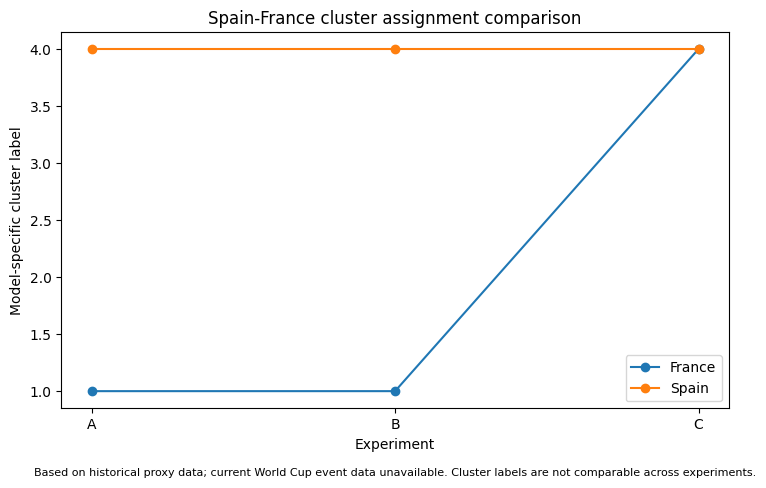

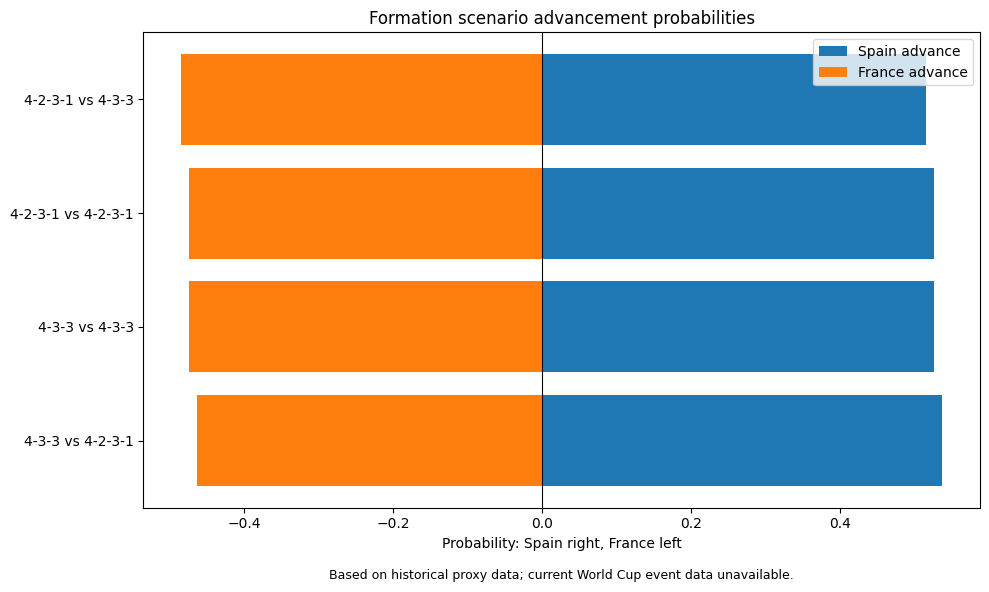

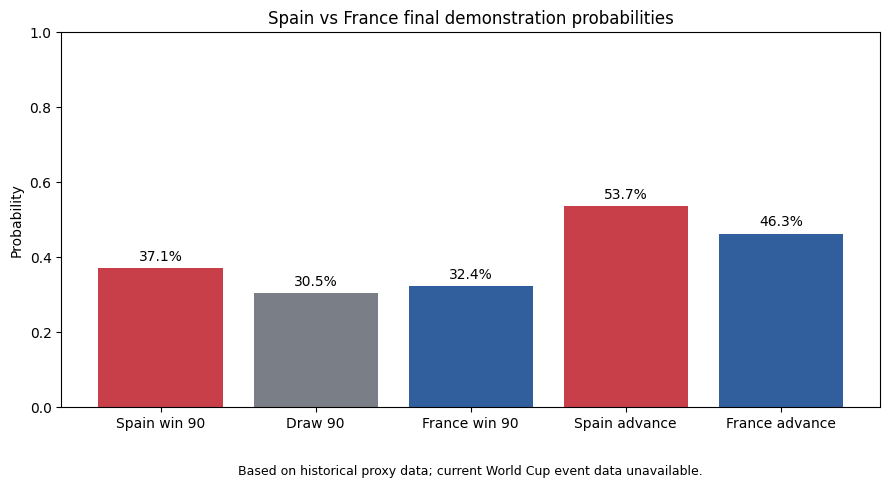

In [16]:
primary_cluster_rows = cluster_assignments[cluster_assignments["experiment"] == primary_experiment]
spain_cluster_row = primary_cluster_rows[primary_cluster_rows["team"] == "Spain"].iloc[0] if not primary_cluster_rows[primary_cluster_rows["team"] == "Spain"].empty else pd.Series(dtype=object)
france_cluster_row = primary_cluster_rows[primary_cluster_rows["team"] == "France"].iloc[0] if not primary_cluster_rows[primary_cluster_rows["team"] == "France"].empty else pd.Series(dtype=object)
primary_style = style_comparison[style_comparison["experiment"] == primary_experiment].iloc[0] if not style_comparison[style_comparison["experiment"] == primary_experiment].empty else pd.Series(dtype=object)

final_summary = pd.DataFrame([{
    "match_name": TARGET_MATCH["match_name"],
    "competition": TARGET_MATCH["competition_name"],
    "round": TARGET_MATCH["round_name"],
    "match_date": TARGET_MATCH["match_date"],
    "neutral_site": TARGET_MATCH["neutral_site"],
    "primary_xT_experiment": primary_experiment,
    "spain_historical_proxy_competition": spain_cluster_row.get("competition", ""),
    "spain_historical_proxy_season": spain_cluster_row.get("season", ""),
    "france_historical_proxy_competition": france_cluster_row.get("competition", ""),
    "france_historical_proxy_season": france_cluster_row.get("season", ""),
    "spain_cluster": spain_cluster_row.get("cluster", np.nan),
    "france_cluster": france_cluster_row.get("cluster", np.nan),
    "xT_cosine_similarity": primary_style.get("xT_cosine_similarity", np.nan),
    "xT_euclidean_distance": primary_style.get("xT_euclidean_distance", np.nan),
    "spain_strength_score": spain_strength,
    "france_strength_score": france_strength,
    "cluster_matchup_sample_size": cluster_matchup_sample_size,
    "tactical_matchup_sample_size": baseline_prediction.get("tactical_sample_size", np.nan),
    "selected_spain_formation": baseline_prediction["spain_formation"],
    "selected_france_formation": baseline_prediction["france_formation"],
    "spain_90_minute_win_probability": baseline_prediction["spain_win_90_probability"],
    "draw_probability": baseline_prediction["draw_90_probability"],
    "france_90_minute_win_probability": baseline_prediction["france_win_90_probability"],
    "spain_advancement_probability": baseline_prediction["spain_advance_probability"],
    "france_advancement_probability": baseline_prediction["france_advance_probability"],
    "predicted_advancing_team": baseline_prediction["predicted_advancing_team"],
    "prediction_confidence": confidence_label,
    "data_limitation_note": "Based on historical proxy data; current World Cup event data unavailable.",
    "prediction_methodology_note": "Transparent rule-based integration of available strength and tactical components; unavailable components were removed and weights renormalized.",
}])
final_summary.to_csv(OUTPUT_DIR / "final_spain_france_prediction.csv", index=False)
display(final_summary)

if not cluster_assignments.empty:
    chart_df = cluster_assignments.copy()
    chart_df["cluster_numeric"] = pd.to_numeric(chart_df["cluster"], errors="coerce")
    fig, ax = plt.subplots(figsize=(8, 5))
    for team, group in chart_df.groupby("team"):
        ax.plot(group["experiment"], group["cluster_numeric"], marker="o", label=team)
    ax.set_title("Spain-France cluster assignment comparison")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Model-specific cluster label")
    ax.legend()
    ax.text(0.5, -0.18, "Based on historical proxy data; current World Cup event data unavailable. Cluster labels are not comparable across experiments.", transform=ax.transAxes, ha="center", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "spain_france_cluster_comparison.png", dpi=160, bbox_inches="tight")
    plt.show()

if not scenario_predictions.empty:
    scenario_chart = scenario_predictions.copy()
    scenario_chart["scenario"] = scenario_chart["spain_formation"] + " vs " + scenario_chart["france_formation"]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(scenario_chart["scenario"], scenario_chart["spain_advance_probability"], label="Spain advance")
    ax.barh(scenario_chart["scenario"], -scenario_chart["france_advance_probability"], label="France advance")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Formation scenario advancement probabilities")
    ax.set_xlabel("Probability: Spain right, France left")
    ax.legend()
    ax.text(0.5, -0.15, "Based on historical proxy data; current World Cup event data unavailable.", transform=ax.transAxes, ha="center", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "spain_france_formation_scenarios.png", dpi=160, bbox_inches="tight")
    plt.show()

labels = ["Spain win 90", "Draw 90", "France win 90", "Spain advance", "France advance"]
values = [baseline_prediction["spain_win_90_probability"], baseline_prediction["draw_90_probability"], baseline_prediction["france_win_90_probability"], baseline_prediction["spain_advance_probability"], baseline_prediction["france_advance_probability"]]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, values, color=["#c83f49", "#7a7f87", "#315f9d", "#c83f49", "#315f9d"])
ax.set_ylim(0, 1)
ax.set_ylabel("Probability")
ax.set_title("Spain vs France final demonstration probabilities")
for i, value in enumerate(values):
    ax.text(i, value + 0.02, f"{value:.1%}", ha="center")
ax.text(0.5, -0.18, "Based on historical proxy data; current World Cup event data unavailable.", transform=ax.transAxes, ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "spain_france_final_probabilities.png", dpi=160, bbox_inches="tight")
plt.show()

## Spain vs France Prediction Interpretation

The final report is generated from calculated outputs and saved as `outputs/spain_france_prediction/spain_france_prediction_report.md`.

In [17]:
def pct(value):
    try:
        return f"{float(value):.1%}"
    except Exception:
        return "n/a"

def top_difference_text(team="Spain", n=3):
    if primary_differences.empty:
        return "No primary xT difference vector was available."
    if team == "Spain":
        rows = primary_differences.sort_values("spain_minus_france", ascending=False).head(n)
        label = "Spain-positive"
    else:
        rows = primary_differences.sort_values("spain_minus_france", ascending=True).head(n)
        label = "France-positive"
    return f"Largest {label} differences: " + ", ".join(f"{r['feature']} ({r['spain_minus_france']:.4f})" for _, r in rows.iterrows())

report = f"""
# Spain vs France Prediction Interpretation

## 1. Data used

The selected Spain historical proxy sample is **{final_summary.loc[0, 'spain_historical_proxy_competition']} {final_summary.loc[0, 'spain_historical_proxy_season']}**. The selected France historical proxy sample is **{final_summary.loc[0, 'france_historical_proxy_competition']} {final_summary.loc[0, 'france_historical_proxy_season']}**.

The xT experiments successfully loaded were **{', '.join(sorted(xt_data.keys()))}**. The primary xT experiment was **Experiment {primary_experiment}**. The tactical statistics file used was **{formation_summary_path if formation_summary is not None else 'none'}**. Strength priors used this source note: **{strength_source_note}**.

## 2. xT style assignments

Spain's primary-experiment cluster is **{final_summary.loc[0, 'spain_cluster']}**. France's primary-experiment cluster is **{final_summary.loc[0, 'france_cluster']}**.

Spain representative cluster teams: {spain_cluster_row.get('representative_teams', 'n/a')}

France representative cluster teams: {france_cluster_row.get('representative_teams', 'n/a')}

Spain distance to centroid: {spain_cluster_row.get('distance_to_centroid', 'n/a')}. France distance to centroid: {france_cluster_row.get('distance_to_centroid', 'n/a')}.

## 3. Spatial tactical comparison

Primary xT cosine similarity: **{final_summary.loc[0, 'xT_cosine_similarity']:.3f}**. Primary xT Euclidean distance: **{final_summary.loc[0, 'xT_euclidean_distance']:.3f}**.

{top_difference_text('Spain')}

{top_difference_text('France')}

Only calculated differences from the selected historical proxy rows are described here. The heatmaps saved in the output directory should be used for spatial interpretation.

## 4. Tactical and formation matchup

The scenario source was **{formation_scenario_source}**. The baseline scenario used for the one-row final summary is **Spain {baseline_prediction['spain_formation']} vs France {baseline_prediction['france_formation']}**.

Among the tested historical scenarios, the highest model-estimated Spain advancement probability came from **Spain {spain_best['spain_formation']} vs France {spain_best['france_formation']}**. The highest model-estimated France advancement probability came from **Spain {france_best['spain_formation']} vs France {france_best['france_formation']}**.

Tactical sample-size limitations are reflected in the scenario confidence notes and the uncertainty table.

## 5. Prediction

The integrated demonstration model suggests:

- Spain 90-minute win probability: **{pct(final_summary.loc[0, 'spain_90_minute_win_probability'])}**
- Draw after 90 minutes: **{pct(final_summary.loc[0, 'draw_probability'])}**
- France 90-minute win probability: **{pct(final_summary.loc[0, 'france_90_minute_win_probability'])}**
- Spain advancement probability: **{pct(final_summary.loc[0, 'spain_advancement_probability'])}**
- France advancement probability: **{pct(final_summary.loc[0, 'france_advancement_probability'])}**
- Predicted advancing team: **{final_summary.loc[0, 'predicted_advancing_team']}**

Based on the available historical proxy data, the model gives a slight advantage to **{final_summary.loc[0, 'predicted_advancing_team']}**. This result is sensitive to the selected formations and fallback assumptions.

## 6. Limitations

No current World Cup event-level data was used. Historical team profiles may not represent the 2026 teams. xT clusters describe attacking threat distribution rather than complete tactics. Defensive pressing, injuries, lineups, player quality, goalkeeper performance, set pieces, and current form may be missing. Formation statistics may have small samples. The final integration weights are transparent demonstration choices rather than optimized parameters. These probabilities should not be used as betting advice.
""".strip()

report_path = OUTPUT_DIR / "spain_france_prediction_report.md"
report_path.write_text(report, encoding="utf-8")
display(Markdown(report))
print(f"Saved {report_path}")

# Spain vs France Prediction Interpretation

## 1. Data used

The selected Spain historical proxy sample is **UEFA Euro 2024**. The selected France historical proxy sample is **UEFA Euro 2024**.

The xT experiments successfully loaded were **A, B, C**. The primary xT experiment was **Experiment C**. The tactical statistics file used was **outputs\formation_matchup_summary.csv**. Strength priors used this source note: **Calculated from available historical proxy xT components; weights renormalized over available components.**.

## 2. xT style assignments

Spain's primary-experiment cluster is **4**. France's primary-experiment cluster is **4**.

Spain representative cluster teams: Arsenal (Premier League, 2015/2016); Real Madrid (La Liga, 2015/2016); Liverpool (Premier League, 2015/2016); Bayer Leverkusen (1. Bundesliga, 2023/2024); Tottenham Hotspur (Premier League, 2015/2016)

France representative cluster teams: Arsenal (Premier League, 2015/2016); Real Madrid (La Liga, 2015/2016); Liverpool (Premier League, 2015/2016); Bayer Leverkusen (1. Bundesliga, 2023/2024); Tottenham Hotspur (Premier League, 2015/2016)

Spain distance to centroid: 13.41146868199235. France distance to centroid: 19.110723062525658.

## 3. Spatial tactical comparison

Primary xT cosine similarity: **0.816**. Primary xT Euclidean distance: **0.126**.

Largest Spain-positive differences: received_z095 (0.0653), created_z045 (0.0268), created_z030 (0.0242)

Largest France-positive differences: created_z062 (-0.0474), received_z159 (-0.0258), received_z173 (-0.0201)

Only calculated differences from the selected historical proxy rows are described here. The heatmaps saved in the output directory should be used for spatial interpretation.

## 4. Tactical and formation matchup

The scenario source was **Local tactical model formation frequencies**. The baseline scenario used for the one-row final summary is **Spain 4-3-3 vs France 4-2-3-1**.

Among the tested historical scenarios, the highest model-estimated Spain advancement probability came from **Spain 4-3-3 vs France 4-2-3-1**. The highest model-estimated France advancement probability came from **Spain 4-2-3-1 vs France 4-3-3**.

Tactical sample-size limitations are reflected in the scenario confidence notes and the uncertainty table.

## 5. Prediction

The integrated demonstration model suggests:

- Spain 90-minute win probability: **37.1%**
- Draw after 90 minutes: **30.5%**
- France 90-minute win probability: **32.4%**
- Spain advancement probability: **53.7%**
- France advancement probability: **46.3%**
- Predicted advancing team: **Spain**

Based on the available historical proxy data, the model gives a slight advantage to **Spain**. This result is sensitive to the selected formations and fallback assumptions.

## 6. Limitations

No current World Cup event-level data was used. Historical team profiles may not represent the 2026 teams. xT clusters describe attacking threat distribution rather than complete tactics. Defensive pressing, injuries, lineups, player quality, goalkeeper performance, set pieces, and current form may be missing. Formation statistics may have small samples. The final integration weights are transparent demonstration choices rather than optimized parameters. These probabilities should not be used as betting advice.

Saved outputs\spain_france_prediction\spain_france_prediction_report.md


## Final Completion Checklist

In [18]:
completed_outputs = [
    OUTPUT_DIR / "project_file_inventory.csv",
    OUTPUT_DIR / "spain_france_cluster_assignments.csv",
    OUTPUT_DIR / "spain_france_xt_profiles.csv",
    OUTPUT_DIR / "spain_france_style_comparison.csv",
    OUTPUT_DIR / "spain_france_formation_scenarios.csv",
    OUTPUT_DIR / "spain_france_strength_prior.csv",
    OUTPUT_DIR / "spain_france_tactical_scenario_predictions.csv",
    OUTPUT_DIR / "prediction_uncertainty.csv",
    OUTPUT_DIR / "final_spain_france_prediction.csv",
    OUTPUT_DIR / "spain_primary_xt_heatmap.png",
    OUTPUT_DIR / "france_primary_xt_heatmap.png",
    OUTPUT_DIR / "spain_minus_france_xt_difference.png",
    OUTPUT_DIR / "spain_france_cluster_comparison.png",
    OUTPUT_DIR / "spain_france_formation_scenarios.png",
    OUTPUT_DIR / "spain_france_final_probabilities.png",
    OUTPUT_DIR / "spain_france_prediction_report.md",
]

checklist = [
    ("Project file discovery", True),
    ("Spain historical sample identification", primary_experiment in spain_reference_rows),
    ("France historical sample identification", primary_experiment in france_reference_rows),
    ("xT cluster assignment", not cluster_assignments.empty),
    ("xT spatial comparison", not style_comparison.empty),
    ("Historical cluster matchup", cluster_component_available),
    ("Tactical statistics lookup", not formation_scenarios.empty),
    ("Strength prior", not strength_prior.empty),
    ("Rule-based probability integration", bool(USE_RULE_BASED_FINAL_PREDICTION)),
    ("Formation scenario analysis", not scenario_predictions.empty),
    ("Final prediction", not final_summary.empty),
    ("Output export", True),
]

for label, ok in checklist:
    status = "Completed" if ok else "Skipped"
    print(f"[{status}] {label}")

print("\nFinal prediction:")
print(f"Predicted advancing team: {final_summary.loc[0, 'predicted_advancing_team']}")
print(f"Spain advancement probability: {final_summary.loc[0, 'spain_advancement_probability']:.3f}")
print(f"France advancement probability: {final_summary.loc[0, 'france_advancement_probability']:.3f}")
print(f"Confidence label: {confidence_label}")
print("Most important limitation: current World Cup event-level data is unavailable; this is a historical proxy proof of concept.")

print("\nFinal output file paths:")
for path in completed_outputs:
    status = "exists" if path.exists() else "not generated in this run"
    print(f"- {path} [{status}]")

[Completed] Project file discovery
[Completed] Spain historical sample identification
[Completed] France historical sample identification
[Completed] xT cluster assignment
[Completed] xT spatial comparison
[Skipped] Historical cluster matchup
[Completed] Tactical statistics lookup
[Completed] Strength prior
[Completed] Rule-based probability integration
[Completed] Formation scenario analysis
[Completed] Final prediction
[Completed] Output export

Final prediction:
Predicted advancing team: Spain
Spain advancement probability: 0.537
France advancement probability: 0.463
Confidence label: Low confidence
Most important limitation: current World Cup event-level data is unavailable; this is a historical proxy proof of concept.

Final output file paths:
- outputs\spain_france_prediction\project_file_inventory.csv [exists]
- outputs\spain_france_prediction\spain_france_cluster_assignments.csv [exists]
- outputs\spain_france_prediction\spain_france_xt_profiles.csv [exists]
- outputs\spain_fra